# Hydro-Risk Price Forecasting Model (NZ Wholesale Electricity)
**Master of Analytics Final Project**  
**Student:** Siddharthan Muthukumaran | **Supervisor:** Shafiq Alam  
**Goal:** Forecast wholesale electricity price risk using hydro storage + flows + spill + HVDC + climate  
**Outputs:** Risk regimes, tail metrics (VaR/CVaR), scenarios (1-in-10/1-in-20), early-warning triggers



## 0. Environment & Reproducibility
This section defines the analytical environment, global settings, helper functions, and folder registry used throughout the pipeline.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 220)

print("Environment initialised successfully.")


Environment initialised successfully.


## 0.1 Project Folder Registry
All raw data folders are registered here so the pipeline is reproducible and portable.


In [5]:
BASE_DIR = Path(r"C:\Users\sidhu\Desktop\Final project files sorted")
DATA_DIR = BASE_DIR

INFRA_DIR   = DATA_DIR / "infrastructure and hydroconstraints Attributes"
DERIVED_ENERGY_DIR = DATA_DIR / "DerivedSeriesForStorageCapacityAndSpecificEnergy"
FLOWS_DIR   = DATA_DIR / "Flows"
TRIBUTARY_DIR = DATA_DIR / "DerivedTributoryFlows"
STORAGE_DIR = DATA_DIR / "Storage"
SPILL_DIR   = DATA_DIR / "spill"
PRICES_DIR  = DATA_DIR / "Final prices Monthly"
HVDC_DIR    = DATA_DIR / "HVDCflows data"
CLIMATE_DIR = DATA_DIR / "NIWA_Climate_Monthly"

OUTPUT_DIR = BASE_DIR / "outputs_notebook"
OUTPUT_DIR.mkdir(exist_ok=True)

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

paths = {
    "INFRA_DIR": INFRA_DIR,
    "DERIVED_ENERGY_DIR": DERIVED_ENERGY_DIR,
    "FLOWS_DIR": FLOWS_DIR,
    "TRIBUTARY_DIR": TRIBUTARY_DIR,
    "STORAGE_DIR": STORAGE_DIR,
    "SPILL_DIR": SPILL_DIR,
    "PRICES_DIR": PRICES_DIR,
    "HVDC_DIR": HVDC_DIR,
    "CLIMATE_DIR": CLIMATE_DIR
}


## 0.2 Path Verification
Sanity check that every required folder exists before loading.


In [7]:
path_check = pd.DataFrame({
    "path_key": list(paths.keys()),
    "path": [str(p) for p in paths.values()],
    "exists": [p.exists() for p in paths.values()],
    "is_dir": [p.is_dir() for p in paths.values()],
})
path_check


,path_key,path,exists,is_dir
0,INFRA_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
1,DERIVED_ENERGY_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
2,FLOWS_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
3,TRIBUTARY_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
4,STORAGE_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
5,SPILL_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
6,PRICES_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
7,HVDC_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True
8,CLIMATE_DIR,C:\Users\sidhu\Desktop\Final project files sor...,True,True


## 1. Data Inventory & File Audit
This section audits file types and counts per folder before loading (prevents silent mistakes).


In [9]:
def audit_folder(path: Path) -> pd.DataFrame:
    files = [f for f in path.iterdir() if f.is_file()]
    return pd.DataFrame({
        "folder": path.name,
        "n_files": len(files),
        "extensions": [sorted({f.suffix.lower() for f in files})]
    })

inventory_summary = pd.concat([audit_folder(p) for p in paths.values()], ignore_index=True)
inventory_summary


,folder,n_files,extensions
0,infrastructure and hydroconstraints Attributes,0,[]
1,DerivedSeriesForStorageCapacityAndSpecificEnergy,2,[.csv]
2,Flows,52,[.csv]
3,DerivedTributoryFlows,14,[.csv]
4,Storage,11,[.csv]
5,spill,26,[.csv]
6,Final prices Monthly,350,[.csv]
7,HVDCflows data,350,[.csv]
8,NIWA_Climate_Monthly,1,[.csv]


## 2. Robust File Reader (CSV + Excel)
Standardised column naming + tolerant reading so we can load all folders consistently.


In [11]:
def standardise_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )
    return df

def read_data_file(path: Path) -> pd.DataFrame | None:
    try:
        if path.suffix.lower() == ".csv":
            df = pd.read_csv(path)
            return standardise_columns(df)

        if path.suffix.lower() in [".xlsx", ".xls"]:
            xls = pd.ExcelFile(path)
            for sheet in xls.sheet_names:
                df = pd.read_excel(xls, sheet_name=sheet)
                if df.shape[0] > 10 and df.shape[1] > 2:
                    return standardise_columns(df)
        return None
    except Exception:
        return None


## 2.1 Load Each Data Folder
We load each folder into a raw table (no aggregation yet) and keep `source_file` for traceability.


In [13]:
def load_folder(folder: Path, label: str) -> pd.DataFrame:
    files = [f for f in folder.iterdir() if f.is_file()]
    tables = []
    for f in files:
        df = read_data_file(f)
        if df is None or df.empty:
            continue
        df["source_file"] = f.name
        df["source_folder"] = label
        tables.append(df)

    if not tables:
        return pd.DataFrame()
    return pd.concat(tables, ignore_index=True, sort=False)

infrastructure_attributes = load_folder(INFRA_DIR, "infrastructure")
derived_energy = load_folder(DERIVED_ENERGY_DIR, "derived_energy")
river_flows = load_folder(FLOWS_DIR, "flows")
tributary_flows = load_folder(TRIBUTARY_DIR, "tributary_flows")
storage_levels = load_folder(STORAGE_DIR, "storage")
spill_data = load_folder(SPILL_DIR, "spill")
prices_raw = load_folder(PRICES_DIR, "prices")
hvdc_raw = load_folder(HVDC_DIR, "hvdc")
climate_raw = load_folder(CLIMATE_DIR, "climate")

{k: v.shape for k, v in {
    "infrastructure": infrastructure_attributes,
    "derived_energy": derived_energy,
    "river_flows": river_flows,
    "tributary_flows": tributary_flows,
    "storage_levels": storage_levels,
    "spill_data": spill_data,
    "prices_raw": prices_raw,
    "hvdc_raw": hvdc_raw,
    "climate_raw": climate_raw
}.items()}


{'infrastructure': (0, 0),
 'derived_energy': (476466, 16),
 'river_flows': (1738566, 19),
 'tributary_flows': (444002, 19),
 'storage_levels': (164390, 14),
 'spill_data': (382521, 12),
 'prices_raw': (124807313, 6),
 'hvdc_raw': (63854, 60),
 'climate_raw': (8430, 19)}

## 2.2 Quick “Raw Peek” (Quality Check)
We confirm schemas and presence of key fields before time alignment.


In [15]:
def peek(df: pd.DataFrame, name: str, n=5):
    print(f"\n{name} — shape: {df.shape}")
    display(df.head(n))
    print("Columns:", list(df.columns)[:25], "..." if df.shape[1] > 25 else "")

peek(prices_raw, "prices_raw")
peek(hvdc_raw, "hvdc_raw")
peek(storage_levels, "storage_levels")
peek(river_flows, "river_flows")
peek(spill_data, "spill_data")



prices_raw — shape: (124807313, 6)


,tradingdate,tradingperiod,pointofconnection,dollarspermegawatthour,source_file,source_folder
0,1996-10-01,1,ABY0111,55.14,199610_FinalEnergyPrices.csv,prices
1,1996-10-01,1,ADD0111,58.04,199610_FinalEnergyPrices.csv,prices
2,1996-10-01,1,ADD0661,57.98,199610_FinalEnergyPrices.csv,prices
3,1996-10-01,1,AHA0111,59.19,199610_FinalEnergyPrices.csv,prices
4,1996-10-01,1,ALB0331,47.86,199610_FinalEnergyPrices.csv,prices


Columns: ['tradingdate', 'tradingperiod', 'pointofconnection', 'dollarspermegawatthour', 'source_file', 'source_folder'] 

hvdc_raw — shape: (63854, 60)


,poc,nwk_code,generation_type,trader,unit_measure,flow_direction,status,trading_date,tp1,tp2,tp3,tp4,tp5,tp6,tp7,tp8,tp9,tp10,tp11,tp12,tp13,tp14,tp15,tp16,tp17,tp18,tp19,tp20,tp21,tp22,tp23,tp24,tp25,tp26,tp27,tp28,tp29,tp30,tp31,tp32,tp33,tp34,tp35,tp36,tp37,tp38,tp39,tp40,tp41,tp42,tp43,tp44,tp45,tp46,tp47,tp48,tp49,tp50,source_file,source_folder
0,HVDC_BN,QQQQ,DC,TPNZ,kWh,X,F,01/10/1996,197550.0,198050.0,186250.0,173100.0,170900.0,135850.0,134050.0,134000.0,133800.0,133800.0,129400.0,114550.0,164500.0,172850.0,211800.0,231850.0,243700.0,241100.0,244350.0,270350.0,261400.0,247750.0,237500.0,237300.0,237200.0,227650.0,206650.0,183900.0,197600.0,192350.0,180400.0,179350.0,179300.0,179150.0,179250.0,208650.0,219750.0,245850.0,257100.0,211200.0,197650.0,239300.0,196400.0,189050.0,180650.0,153850.0,90800.0,79100.0,NaN,NaN,199610_HVDC_flows.csv,hvdc
1,HVDC_BN,QQQQ,DC,TPNZ,kWh,X,F,02/10/1996,97300.0,133600.0,126000.0,118000.0,83700.0,66700.0,64600.0,84000.0,83900.0,83200.0,80000.0,113500.0,113700.0,136850.0,175050.0,225050.0,227350.0,227250.0,197450.0,188450.0,182750.0,183000.0,174050.0,173600.0,193500.0,202900.0,188050.0,198650.0,227550.0,227500.0,234800.0,237400.0,237350.0,276250.0,275000.0,267300.0,277150.0,297050.0,296500.0,288900.0,278900.0,276950.0,276600.0,306900.0,364550.0,360450.0,304450.0,291900.0,NaN,NaN,199610_HVDC_flows.csv,hvdc
2,HVDC_BN,QQQQ,DC,TPNZ,kWh,X,F,03/10/1996,293700.0,320750.0,316800.0,306450.0,361350.0,390200.0,402750.0,412700.0,419950.0,419250.0,409750.0,401850.0,381900.0,324050.0,320800.0,296550.0,296550.0,296500.0,296300.0,296400.0,296650.0,297450.0,311350.0,318800.0,322550.0,328150.0,342550.0,342200.0,340800.0,340800.0,337050.0,336300.0,336200.0,335900.0,342400.0,360200.0,359800.0,335700.0,306950.0,301450.0,301600.0,316250.0,356600.0,380100.0,380350.0,373400.0,351150.0,360650.0,NaN,NaN,199610_HVDC_flows.csv,hvdc
3,HVDC_BN,QQQQ,DC,TPNZ,kWh,X,F,04/10/1996,333100.0,284150.0,300500.0,293600.0,286150.0,290150.0,305950.0,306300.0,320850.0,310800.0,292600.0,315800.0,330250.0,388700.0,411200.0,401100.0,387700.0,387650.0,395900.0,395450.0,355150.0,338650.0,335900.0,336450.0,336500.0,336250.0,336750.0,353450.0,365650.0,364200.0,361850.0,375700.0,375900.0,385800.0,368250.0,343200.0,340450.0,341750.0,340850.0,340550.0,341000.0,340900.0,317850.0,335650.0,360500.0,322100.0,286850.0,271600.0,NaN,NaN,199610_HVDC_flows.csv,hvdc
4,HVDC_BN,QQQQ,DC,TPNZ,kWh,X,F,05/10/1996,263900.0,155200.0,137950.0,136450.0,118400.0,104250.0,103750.0,93550.0,88750.0,88900.0,88800.0,101700.0,155500.0,204400.0,299450.0,350900.0,350950.0,351050.0,364850.0,365700.0,358000.0,354050.0,324500.0,311900.0,272700.0,267550.0,262250.0,282200.0,286700.0,286900.0,287000.0,286250.0,237800.0,270250.0,281850.0,318850.0,346150.0,361100.0,365150.0,365450.0,365300.0,365450.0,337550.0,319650.0,287300.0,286450.0,285600.0,217150.0,NaN,NaN,199610_HVDC_flows.csv,hvdc


Columns: ['poc', 'nwk_code', 'generation_type', 'trader', 'unit_measure', 'flow_direction', 'status', 'trading_date', 'tp1', 'tp2', 'tp3', 'tp4', 'tp5', 'tp6', 'tp7', 'tp8', 'tp9', 'tp10', 'tp11', 'tp12', 'tp13', 'tp14', 'tp15', 'tp16', 'tp17'] ...

storage_levels — shape: (164390, 14)


...

Columns: ['filename', 'description', 'plantgroup', 'sitecode', 'islandcode', 'island', 'source_file', 'source_folder', 'date', 'time', 'lake_level_m', 'active_storage_mm', 'active_contingent_storage_mm', 'qualitycode'] 

river_flows — shape: (1738566, 19)


,filename,description,plantgroup,sitecode,site,directioncode,direction,flowtypecode,flowtype,islandcode,island,sitenumber,modelflowname,source_file,source_folder,date,time,flow_ms,qualitycode
0,NI_MHO_Actual_MangahaoStation_Inflow_97502(1).csv,Local inflows,Mangahao,MHO,Mangahao,I,Inflow,A,Actual,NI,North Island,97502.1,Mangahao,FileIndex_Flows.csv,flows,NaN,NaN,NaN,NaN
1,NI_MAT_Actual_LakeMatahina_Inflow_93254(1).csv,Matahina Inflows,Matahina,MAT,Matahina,I,Inflow,A,Actual,NI,North Island,93254.1,Matahina,FileIndex_Flows.csv,flows,NaN,NaN,NaN,NaN
2,NI_NA_Natural_MohakaRiverAtRaupunga_Flow_12180...,Mohaka River flow at Mohaka at Raupunga,Mohaka (potential),NaN,Raupunga,F,Flow,N+A,Natural/Actual,NI,North Island,121801.1,Raupunga,FileIndex_Flows.csv,flows,NaN,NaN,NaN,NaN
3,NI_NA_Natural_NgaruroroRiverAtWhanawhana_Flow_...,Ngaruroro River flow at Whanawhana recorder,Ngaruroro (potential),NaN,Whanawhana,F,Flow,N+A,Natural/Actual,NI,North Island,123103.1,Whanawhana,FileIndex_Flows.csv,flows,NaN,NaN,NaN,NaN
4,NI_NA_Natural_NgaruroroRiverAtKuripapango_Flow...,Ngaruroro River flow at Kuripapango recorder,Ngaruroro (potential),NaN,Kuripapango,F,Flow,N+A,Natural/Actual,NI,North Island,123104.1,Kuripapango,FileIndex_Flows.csv,flows,NaN,NaN,NaN,NaN


Columns: ['filename', 'description', 'plantgroup', 'sitecode', 'site', 'directioncode', 'direction', 'flowtypecode', 'flowtype', 'islandcode', 'island', 'sitenumber', 'modelflowname', 'source_file', 'source_folder', 'date', 'time', 'flow_ms', 'qualitycode'] 

spill_data — shape: (382521, 12)


,filename,description,plantgroup,sitecode,islandcode,island,source_file,source_folder,date,time,spill_mm,qualitycode
0,NI_PRI_Spill_WaikaretehekeRiverAtPiripaua.csv,Waikareteheke River at Piripaua,Waikaremoana,PRI,NI,North Island,FileIndex_Spill.csv,spill,NaN,NaN,NaN,NaN
1,NI_TUI_Spill_WaikaretehekeRiverAtUpstreamManga...,Waikareteheke River at upstream Mangaone (Min ...,Waikaremoana,TUI,NI,North Island,FileIndex_Spill.csv,spill,NaN,NaN,NaN,NaN
2,NI_WKA_Spill_LakeWaikaremoanaAtOnepoto.csv,Waikaremoana dam spill at Onepoto,Waikaremoana,WKA,NI,North Island,FileIndex_Spill.csv,spill,NaN,NaN,NaN,NaN
3,NI_TPO_Spill_LakeTaupo.csv,Lake Taupo outflow/spill,Waikato river,TPO,NI,North Island,FileIndex_Spill.csv,spill,NaN,NaN,NaN,NaN
4,NI_ARA_Spill_LakeAratiatia.csv,Aratiatia spill,Waikato river,ARA,NI,North Island,FileIndex_Spill.csv,spill,NaN,NaN,NaN,NaN


Columns: ['filename', 'description', 'plantgroup', 'sitecode', 'islandcode', 'island', 'source_file', 'source_folder', 'date', 'time', 'spill_mm', 'qualitycode'] 


## 2.3 Date Parsing & Time Alignment

All datasets originate from different sources and temporal resolutions 
(trading-period, daily, monthly, and multi-decadal records).  
To enable consistent integration and modelling, all date fields are converted 
to a standard `datetime` format and aligned to a common monthly key (`YearMonth`).

Two modelling windows are defined:

- **Full-system window (1996–2019)**: includes HVDC flows and all hydro variables  
- **Extended hydro window (1996–2024)**: includes hydro, inflows, storage, spill, 
  and climate data, but excludes HVDC due to data availability constraints

This separation allows full-system analysis where possible, while preserving 
long-run hydro risk dynamics for extended analysis.


In [17]:
# ============================================================
# 2.3 Date Parsing & Time Alignment (MEMORY SAFE)
# ============================================================

def ensure_datetime_inplace(df: pd.DataFrame, col: str, dayfirst: bool = False) -> pd.DataFrame:
    """
    Convert ONE column to datetime WITHOUT copying the full dataframe.
    This is critical for huge tables (e.g., prices_raw).
    """
    if col in df.columns and not np.issubdtype(df[col].dtype, np.datetime64):
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=dayfirst)
    return df


def add_yearmonth_inplace(df: pd.DataFrame, date_col: str, out_col: str = "YearMonth") -> pd.DataFrame:
    """
    Add YearMonth WITHOUT copying full df.
    """
    if date_col in df.columns:
        df[out_col] = df[date_col].dt.to_period("M").dt.to_timestamp()
    return df


# -------------------------
# Prices (HUGE) - do NOT copy
# -------------------------
# Prefer 'tradingdate' if present; else fallback to 'trading_date'
if "tradingdate" in prices_raw.columns:
    prices_raw = ensure_datetime_inplace(prices_raw, "tradingdate", dayfirst=False)
    prices_raw = add_yearmonth_inplace(prices_raw, "tradingdate")
elif "trading_date" in prices_raw.columns:
    prices_raw = ensure_datetime_inplace(prices_raw, "trading_date", dayfirst=False)
    prices_raw = add_yearmonth_inplace(prices_raw, "trading_date")

# -------------------------
# HVDC - dayfirst strings like 01/10/1996
# -------------------------
if "trading_date" in hvdc_raw.columns:
    hvdc_raw = ensure_datetime_inplace(hvdc_raw, "trading_date", dayfirst=True)
    hvdc_raw = add_yearmonth_inplace(hvdc_raw, "trading_date")
elif "tradingdate" in hvdc_raw.columns:
    hvdc_raw = ensure_datetime_inplace(hvdc_raw, "tradingdate", dayfirst=True)
    hvdc_raw = add_yearmonth_inplace(hvdc_raw, "tradingdate")

# -------------------------
# Hydro datasets (smaller) - safe inplace too
# -------------------------
for d, datecol in [
    (river_flows, "date"),
    (tributary_flows, "date"),
    (storage_levels, "date"),
    (spill_data, "date"),
]:
    ensure_datetime_inplace(d, datecol, dayfirst=False)
    add_yearmonth_inplace(d, datecol)

# Climate (monthly anchor datemin)
if "datemin" in climate_raw.columns:
    climate_raw = ensure_datetime_inplace(climate_raw, "datemin", dayfirst=False)
    climate_raw = add_yearmonth_inplace(climate_raw, "datemin")


## 2.4 Coverage & Two Modelling Windows (Memory-Safe)

Because `prices_raw` is extremely large (tens of millions of rows), we **do not filter it at the raw trading-period level**.
Instead we:
1) Convert only the required date column
2) Create `YearMonth`
3) Aggregate to monthly immediately (tiny table)
4) Apply modelling windows on monthly tables (safe)

We maintain two panels:
- **Full-system panel (1996–2019):** includes HVDC
- **Extended panel (1996–2024):** excludes HVDC (hydro/climate only)


In [19]:
START_DATE = pd.Timestamp("1996-10-01")
END_FULL_SYSTEM = pd.Timestamp("2019-12-01")   # last year with HVDC coverage
END_EXTENDED    = pd.Timestamp("2024-12-01")   # last year with hydro/flows/storage/spill coverage

def filter_monthly(df_m: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    # monthly df only (small) -> safe to copy
    return df_m.loc[(df_m["YearMonth"] >= start) & (df_m["YearMonth"] <= end)].copy()


## 3. Monthly Aggregation (Memory-Safe)

### 3.1 Prices - Monthly National Mean (critical memory step)
Prices are at trading-period level and extremely large, so we only keep:
- trading date
- price column

Then aggregate immediately to `YearMonth`.


In [21]:
# -----------------------------
# PRICES: ultra memory-safe monthly aggregation (FIXED)
# -----------------------------

# unify date col name
if "tradingdate" not in prices_raw.columns and "trading_date" in prices_raw.columns:
    prices_raw = prices_raw.rename(columns={"trading_date": "tradingdate"})

td = pd.to_datetime(prices_raw["tradingdate"], errors="coerce", cache=True)
px = prices_raw["dollarspermegawatthour"]

# month key (numpy month)
ym = td.values.astype("datetime64[M]")

# groupby month key (NaT auto dropped)
prices_monthly_all = (
    pd.Series(px.to_numpy(), name="Price_mean")
      .groupby(ym)
      .mean()
      .reset_index()
      .rename(columns={"index": "YearMonth"})
)

# convert the small monthly output to month-start Timestamp
prices_monthly_all["YearMonth"] = pd.to_datetime(prices_monthly_all["YearMonth"]).dt.to_period("M").dt.to_timestamp()
prices_monthly_all = prices_monthly_all.sort_values("YearMonth").reset_index(drop=True)

prices_monthly_all.head(), prices_monthly_all.shape


(   YearMonth  Price_mean
 0 1996-10-01   38.863244
 1 1996-11-01   41.102198
 2 1996-12-01   35.425693
 3 1997-01-01   41.016910
 4 1997-02-01   51.489081,
 (350, 2))

In [22]:
# -----------------------------
# HVDC: memory-safe monthly aggregation (1996–2019 coverage)
# -----------------------------

hv = hvdc_raw

# 1) parse trading_date (dayfirst in your file)
td = pd.to_datetime(hv["trading_date"], dayfirst=True, errors="coerce", cache=True)

# 2) month key (numpy month)
ym = td.values.astype("datetime64[M]")

# 3) TP columns
tp_cols = [c for c in hv.columns if c.startswith("tp")]
if len(tp_cols) == 0:
    raise ValueError("No TP columns found (expected tp1..tp50).")

# 4) daily mean across TP columns (compute in-place without copying whole df)
tp_vals = hv[tp_cols].to_numpy(dtype="float32", copy=False)
hvdc_daily_mean = np.nanmean(tp_vals, axis=1)

# 5) monthly mean of daily means
hvdc_monthly_all = (
    pd.Series(hvdc_daily_mean, name="HVDC_mean")
      .groupby(ym)
      .mean()
      .reset_index()
      .rename(columns={"index": "YearMonth"})
)

# 6) month-start timestamps
hvdc_monthly_all["YearMonth"] = pd.to_datetime(hvdc_monthly_all["YearMonth"]).dt.to_period("M").dt.to_timestamp()
hvdc_monthly_all = hvdc_monthly_all.sort_values("YearMonth").reset_index(drop=True)

hvdc_monthly_all.head(), hvdc_monthly_all.shape


(   YearMonth      HVDC_mean
 0 1996-10-01  172277.500000
 1 1996-11-01  191954.281250
 2 1996-12-01  164963.625000
 3 1997-01-01  179656.968750
 4 1997-02-01   64621.105469,
 (279, 2))

In [23]:
# Hydro monthly (flows / storage / spill)
def _monthly_mean_from_date_value(df, date_col, value_col, dayfirst=False, out_name=None):
    td = pd.to_datetime(df[date_col], errors="coerce", dayfirst=dayfirst, cache=True)
    ym = td.values.astype("datetime64[M]")
    s = pd.Series(df[value_col].to_numpy(), name=out_name or value_col)
    out = (
        s.groupby(ym).mean()
         .reset_index()
         .rename(columns={"index": "YearMonth", (out_name or value_col): (out_name or value_col)})
    )
    out["YearMonth"] = pd.to_datetime(out["YearMonth"]).dt.to_period("M").dt.to_timestamp()
    return out.sort_values("YearMonth").reset_index(drop=True)

flows_monthly_all   = _monthly_mean_from_date_value(river_flows,     "date", "flow_ms",          out_name="RiverFlow_mean")
trib_monthly_all    = _monthly_mean_from_date_value(tributary_flows, "date", "flow_ms",          out_name="TributaryFlow_mean")
storage_monthly_all = _monthly_mean_from_date_value(storage_levels,  "date", "active_storage_mm", out_name="Storage_active_mm")
spill_monthly_all   = _monthly_mean_from_date_value(spill_data,      "date", "spill_mm",          out_name="Spill_mean_mm")

flows_monthly_all.head(), storage_monthly_all.shape


(   YearMonth  RiverFlow_mean
 0 1931-07-01       89.061805
 1 1931-08-01       74.174107
 2 1931-09-01       76.430920
 3 1931-10-01      124.045696
 4 1931-11-01      116.560825,
 (540, 2))

In [24]:
# Climate monthly
cl = climate_raw.copy()

# month key from datemin (already monthly-ish)
td = pd.to_datetime(cl["datemin"], errors="coerce", cache=True)
ym = td.values.astype("datetime64[M]")

num_cols = cl.select_dtypes(include="number").columns.tolist()

# if your numeric columns are only agentno/version (metadata), keep them but flag it
climate_monthly_all = (
    cl[num_cols]
    .assign(_ym=ym)
    .groupby("_ym", as_index=False)
    .mean()
    .rename(columns={"_ym": "YearMonth"})
)

climate_monthly_all["YearMonth"] = pd.to_datetime(climate_monthly_all["YearMonth"]).dt.to_period("M").dt.to_timestamp()
climate_monthly_all = climate_monthly_all.sort_values("YearMonth").reset_index(drop=True)

climate_monthly_all.head(), climate_monthly_all.shape


(   YearMonth  agentno  version
 0 1852-11-01  22645.0      0.1
 1 1853-01-01   1427.0      0.1
 2 1853-10-01   1427.0      0.1
 3 1862-02-01   3383.0      0.1
 4 1862-03-01   3383.0      0.1,
 (1377, 3))

In [25]:
# Build TWO PANELS
START_DATE = pd.Timestamp("1996-10-01")
END_FULL_SYSTEM = pd.Timestamp("2019-12-01")
END_EXTENDED    = pd.Timestamp("2024-12-01")

def _clip_window(df, start, end):
    return df[(df["YearMonth"] >= start) & (df["YearMonth"] <= end)].sort_values("YearMonth").reset_index(drop=True)

# Panel A: FULL system (has HVDC)
tables_full = [
    _clip_window(prices_monthly_all, START_DATE, END_FULL_SYSTEM),
    _clip_window(hvdc_monthly_all,   START_DATE, END_FULL_SYSTEM),
    _clip_window(flows_monthly_all,  START_DATE, END_FULL_SYSTEM),
    _clip_window(trib_monthly_all,   START_DATE, END_FULL_SYSTEM),
    _clip_window(storage_monthly_all,START_DATE, END_FULL_SYSTEM),
    _clip_window(spill_monthly_all,  START_DATE, END_FULL_SYSTEM),
    _clip_window(climate_monthly_all,START_DATE, END_FULL_SYSTEM),
]

from functools import reduce
panel_full = reduce(lambda L,R: pd.merge(L, R, on="YearMonth", how="left"), tables_full)

# Panel B: EXTENDED hydro (NO HVDC)
tables_ext = [
    _clip_window(prices_monthly_all, START_DATE, END_EXTENDED),
    _clip_window(flows_monthly_all,  START_DATE, END_EXTENDED),
    _clip_window(trib_monthly_all,   START_DATE, END_EXTENDED),
    _clip_window(storage_monthly_all,START_DATE, END_EXTENDED),
    _clip_window(spill_monthly_all,  START_DATE, END_EXTENDED),
    _clip_window(climate_monthly_all,START_DATE, END_EXTENDED),
]
panel_ext = reduce(lambda L,R: pd.merge(L, R, on="YearMonth", how="left"), tables_ext)

panel_full.shape, panel_ext.shape, panel_full.head()


((279, 9),
 (339, 8),
    YearMonth  Price_mean      HVDC_mean  RiverFlow_mean  TributaryFlow_mean  Storage_active_mm  Spill_mean_mm       agentno  version
 0 1996-10-01   38.863244  172277.500000      176.649771           59.457491         530.774687       8.150981  13609.214286      0.1
 1 1996-11-01   41.102198  191954.281250      125.514597           41.518382         505.649523       3.444109  12500.636364      0.1
 2 1996-12-01   35.425693  164963.625000      122.269655           33.060481         496.895584       2.533831           NaN      NaN
 3 1997-01-01   41.016910  179656.968750       73.815594           29.784844         471.820842       2.205988  13573.250000      0.1
 4 1997-02-01   51.489081   64621.105469       91.707691           26.872489         425.661714       1.343006  10695.000000      0.1)

# 4. Exploratory Data Analysis (EDA)

This section provides a visual and descriptive exploration of NZ wholesale electricity
prices and hydro system variables.

The goal is to:
- understand baseline behaviour and seasonality
- identify key relationships and non-linear patterns
- motivate the hypotheses and regime definitions tested later

No formal statistical testing is conducted in this section.


## 4.1 Wholesale Electricity Price Behaviour
We begin by examining the level, distribution, and seasonality of prices.


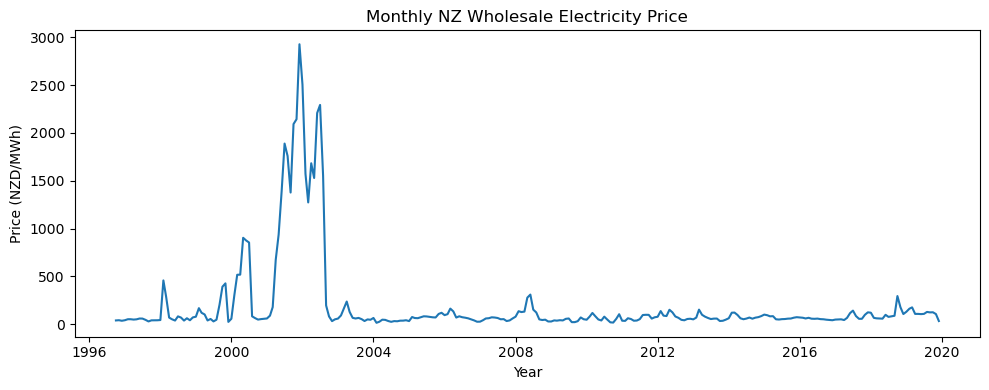

In [234]:
#Price time series
plt.figure(figsize=(10,4))
plt.plot(panel_full["YearMonth"], panel_full["Price_mean"])
plt.title("Monthly NZ Wholesale Electricity Price")
plt.xlabel("Year")
plt.ylabel("Price (NZD/MWh)")
plt.tight_layout()
plt.show()


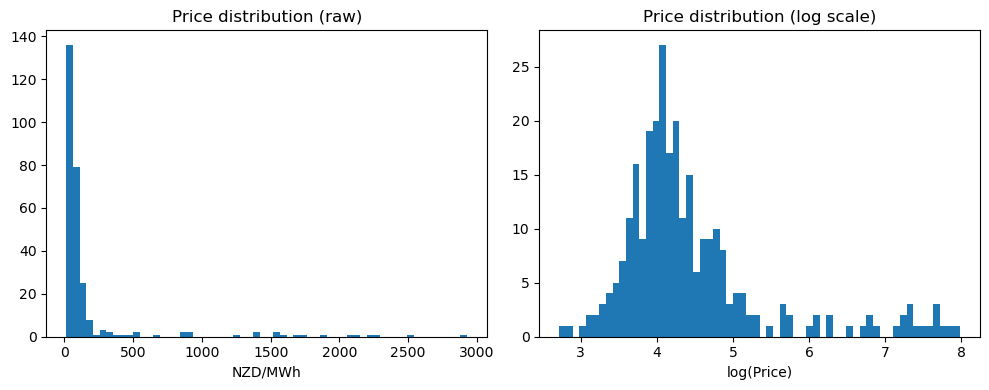

In [235]:
#Price distribution (raw + log)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(panel_full["Price_mean"], bins=60)
plt.title("Price distribution (raw)")
plt.xlabel("NZD/MWh")

plt.subplot(1,2,2)
plt.hist(np.log1p(panel_full["Price_mean"]), bins=60)
plt.title("Price distribution (log scale)")
plt.xlabel("log(Price)")

plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

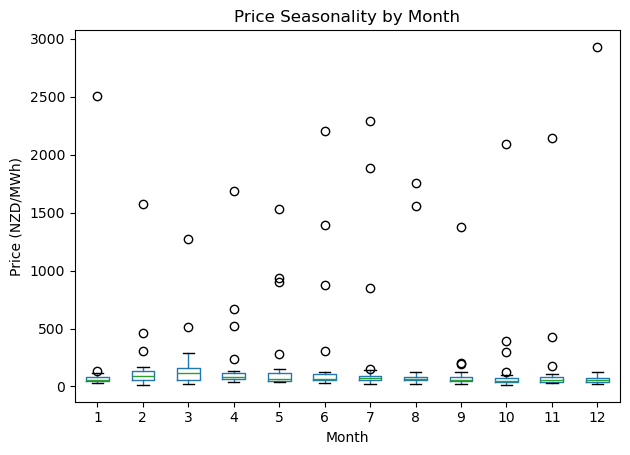

In [237]:
#Price seasonality
tmp = panel_full.copy()
tmp["Month"] = tmp["YearMonth"].dt.month

plt.figure(figsize=(8,4))
tmp.boxplot(column="Price_mean", by="Month", grid=False)
plt.title("Price Seasonality by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Price (NZD/MWh)")
plt.tight_layout()
plt.show()


**EDA insights**
- Prices are highly persistent with occasional extreme spikes
- The distribution is strongly right-skewed
- Winter months show higher dispersion and upside risk


## 4.2 Hydro Storage Dynamics
We examine the behaviour of national hydro storage and its relationship with prices.


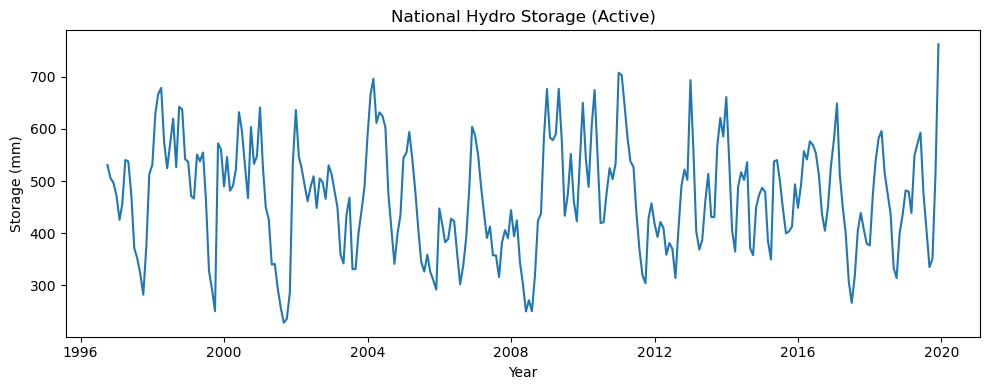

In [241]:
#Storage time series
plt.figure(figsize=(10,4))
plt.plot(panel_full["YearMonth"], panel_full["Storage_active_mm"])
plt.title("National Hydro Storage (Active)")
plt.xlabel("Year")
plt.ylabel("Storage (mm)")
plt.tight_layout()
plt.show()


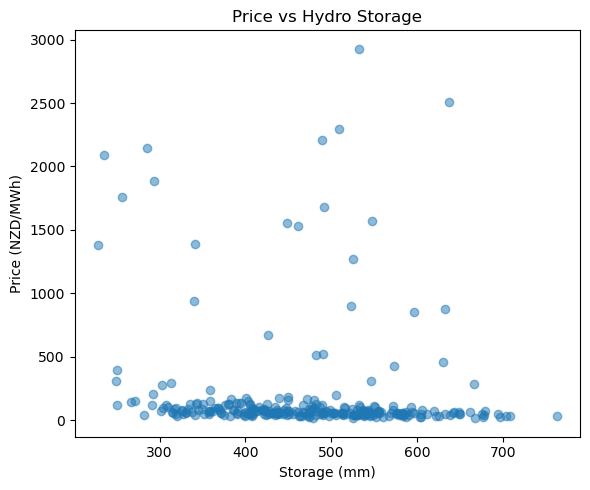

In [243]:
#Storage vs price scatter
plt.figure(figsize=(6,5))
plt.scatter(
    panel_full["Storage_active_mm"],
    panel_full["Price_mean"],
    alpha=0.5
)
plt.xlabel("Storage (mm)")
plt.ylabel("Price (NZD/MWh)")
plt.title("Price vs Hydro Storage")
plt.tight_layout()
plt.show()


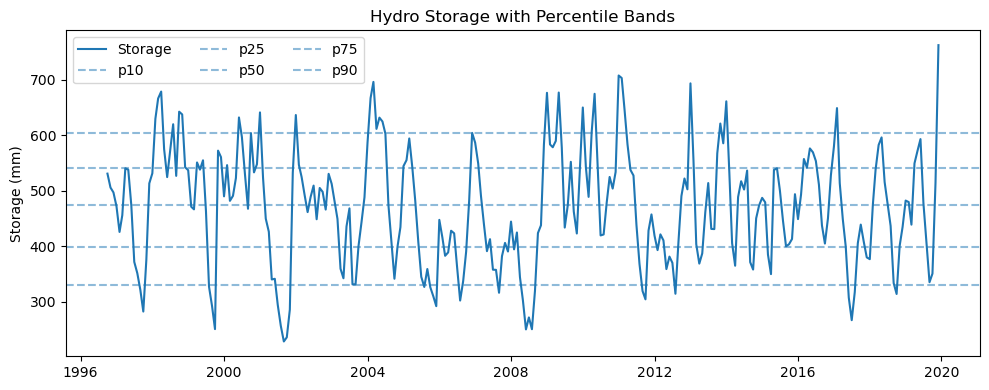

In [244]:
#Storage percentile bands
s = panel_full["Storage_active_mm"].dropna()
pcts = np.percentile(s, [10,25,50,75,90])

plt.figure(figsize=(10,4))
plt.plot(panel_full["YearMonth"], panel_full["Storage_active_mm"], label="Storage")

for p, lab in zip(pcts, ["p10","p25","p50","p75","p90"]):
    plt.axhline(p, linestyle="--", alpha=0.5, label=lab)

plt.legend(ncol=3)
plt.title("Hydro Storage with Percentile Bands")
plt.ylabel("Storage (mm)")
plt.tight_layout()
plt.show()


**EDA insights**
- Low-storage periods occur in clear multi-month episodes
- Prices rise sharply as storage approaches lower percentiles
- Percentile thresholds provide natural regime cut-offs


## 4.3 Inflows & Tributary Flows
Inflows determine storage evolution and signal hydro stress.


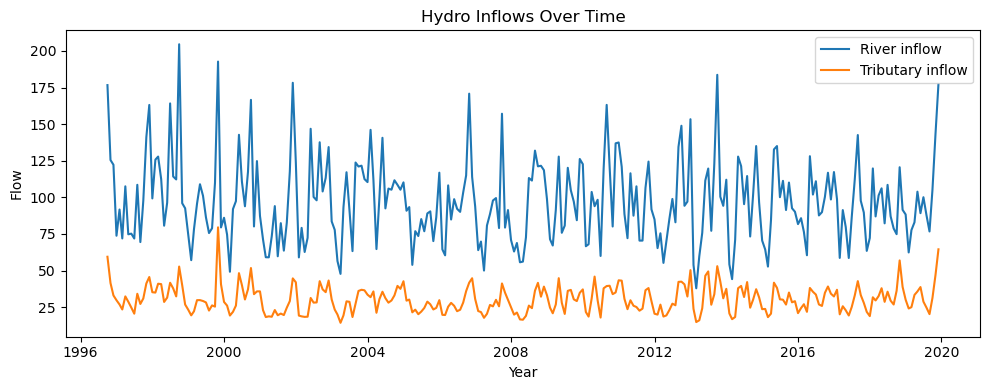

In [250]:
#Inflow time series
plt.figure(figsize=(10,4))
plt.plot(panel_full["YearMonth"], panel_full["RiverFlow_mean"], label="River inflow")
plt.plot(panel_full["YearMonth"], panel_full["TributaryFlow_mean"], label="Tributary inflow")
plt.legend()
plt.title("Hydro Inflows Over Time")
plt.xlabel("Year")
plt.ylabel("Flow")
plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

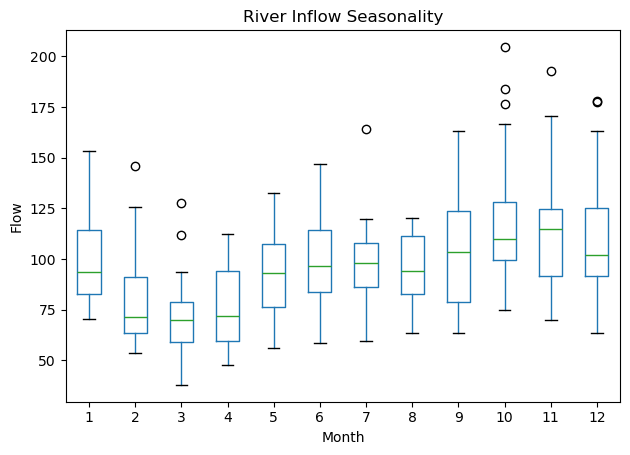

In [251]:
#Inflow seasonality
tmp = panel_full.copy()
tmp["Month"] = tmp["YearMonth"].dt.month

plt.figure(figsize=(8,4))
tmp.boxplot(column="RiverFlow_mean", by="Month", grid=False)
plt.title("River Inflow Seasonality")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Flow")
plt.tight_layout()
plt.show()


**EDA insights**
- Inflows are strongly seasonal
- Storage stress reflects prolonged low-inflow sequences rather than single shocks


## 4.4 Spill Behaviour (System Abundance)
Spill indicates surplus conditions and binding physical constraints.


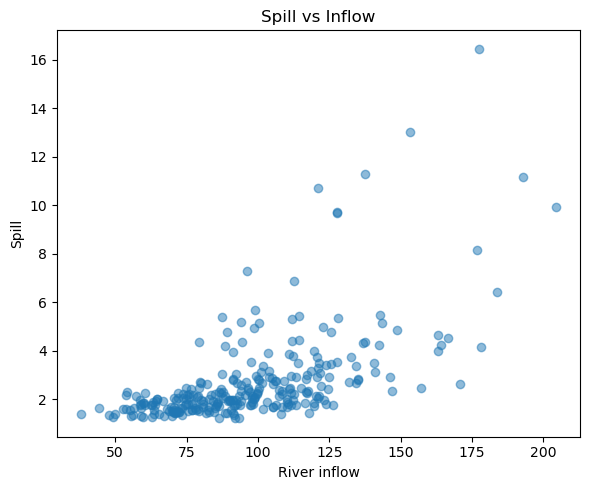

In [255]:
#Spill vs inflow
plt.figure(figsize=(6,5))
plt.scatter(
    panel_full["RiverFlow_mean"],
    panel_full["Spill_mean_mm"],
    alpha=0.5
)
plt.xlabel("River inflow")
plt.ylabel("Spill")
plt.title("Spill vs Inflow")
plt.tight_layout()
plt.show()


**EDA insights**
- Spill increases non-linearly beyond inflow thresholds
- Confirms asymmetric system behaviour between scarcity and abundance


## 4.5 HVDC Flows (System Stress Proxy)
HVDC transfers reflect inter-island balancing under stress.


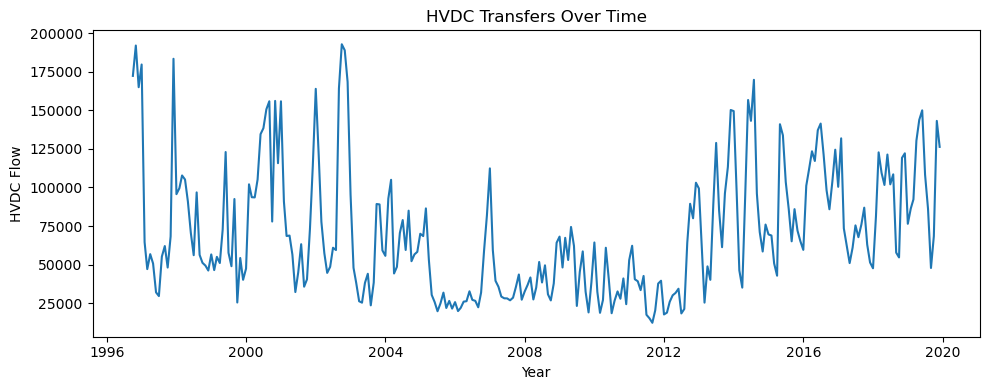

In [259]:
#HVDC time series
plt.figure(figsize=(10,4))
plt.plot(panel_full["YearMonth"], panel_full["HVDC_mean"])
plt.title("HVDC Transfers Over Time")
plt.xlabel("Year")
plt.ylabel("HVDC Flow")
plt.tight_layout()
plt.show()

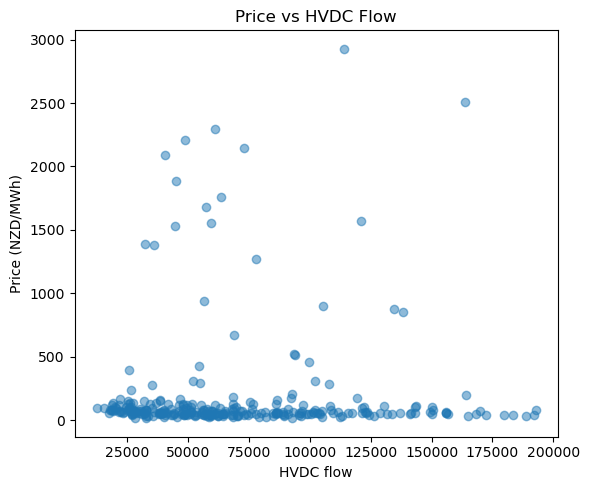

In [260]:
# HVDC vs price
plt.figure(figsize=(6,5))
plt.scatter(
    panel_full["HVDC_mean"],
    panel_full["Price_mean"],
    alpha=0.5
)
plt.xlabel("HVDC flow")
plt.ylabel("Price (NZD/MWh)")
plt.title("Price vs HVDC Flow")
plt.tight_layout()
plt.show()

**EDA insights**
- HVDC activity increases during system stress
- Relationship with prices strengthens during scarcity periods


## 4.6 Correlation & Lag Structure
We examine contemporaneous correlations and simple lag relationships.


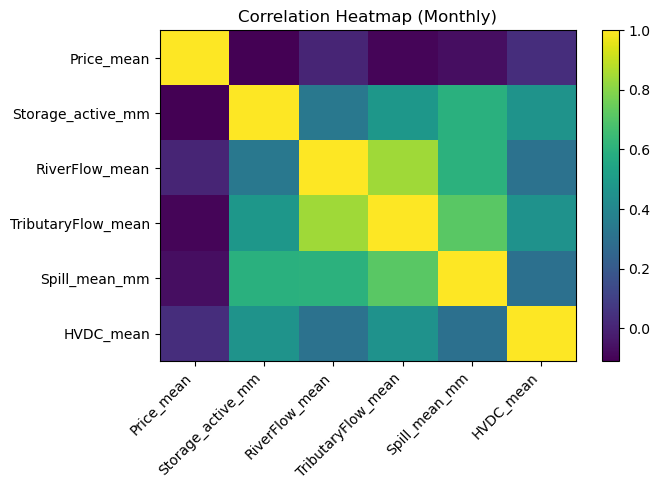

In [263]:
#Correlation heatmap
eda_cols = [
    "Price_mean",
    "Storage_active_mm",
    "RiverFlow_mean",
    "TributaryFlow_mean",
    "Spill_mean_mm",
    "HVDC_mean"
]

corr = panel_full[eda_cols].corr()

plt.figure(figsize=(7,5))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(eda_cols)), eda_cols, rotation=45, ha="right")
plt.yticks(range(len(eda_cols)), eda_cols)
plt.title("Correlation Heatmap (Monthly)")
plt.colorbar()
plt.tight_layout()
plt.show()


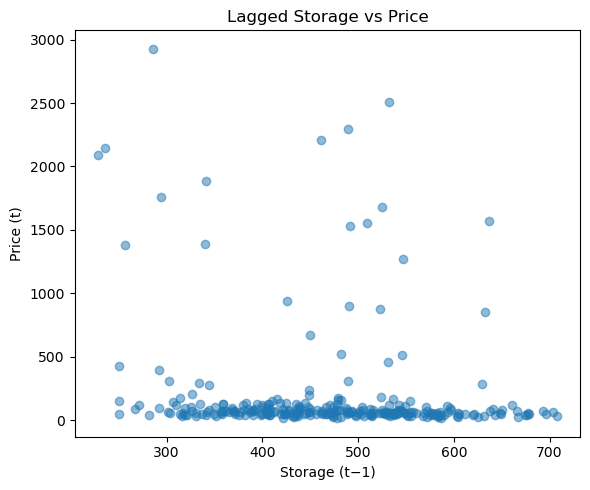

In [264]:
#Lag intuition (storage lag)
plt.figure(figsize=(6,5))
plt.scatter(
    panel_full["Storage_active_mm"].shift(1),
    panel_full["Price_mean"],
    alpha=0.5
)
plt.xlabel("Storage (t−1)")
plt.ylabel("Price (t)")
plt.title("Lagged Storage vs Price")
plt.tight_layout()
plt.show()


**EDA insights**
- Lagged storage shows clearer relationship with price than contemporaneous storage
- Supports lag-based features in hypothesis testing and modelling


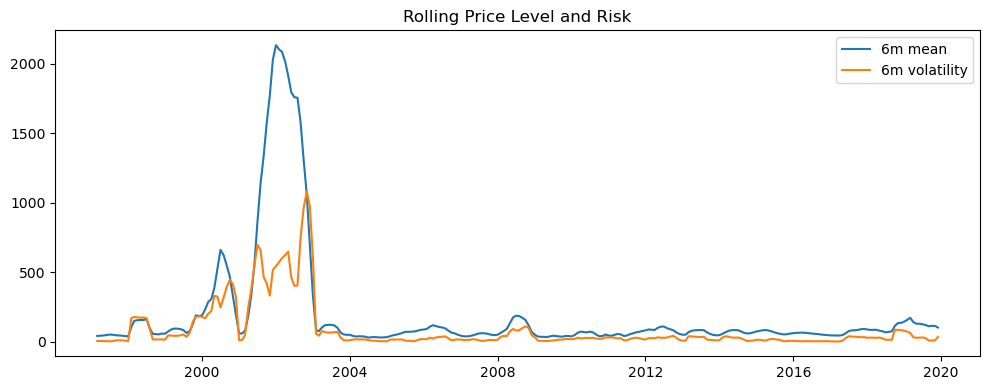

In [267]:
# Rolling volatility & rolling mean (price dynamics)
panel_full["Price_roll6"] = panel_full["Price_mean"].rolling(6).mean()
panel_full["Price_vol6"]  = panel_full["Price_mean"].rolling(6).std()

plt.figure(figsize=(10,4))
plt.plot(panel_full["YearMonth"], panel_full["Price_roll6"], label="6m mean")
plt.plot(panel_full["YearMonth"], panel_full["Price_vol6"], label="6m volatility")
plt.legend()
plt.title("Rolling Price Level and Risk")
plt.tight_layout()
plt.show()


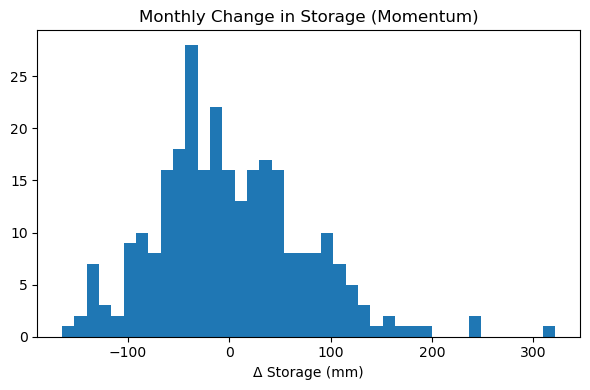

In [268]:
# Storage change (momentum)
panel_full["dStorage"] = panel_full["Storage_active_mm"].diff()

plt.figure(figsize=(6,4))
plt.hist(panel_full["dStorage"].dropna(), bins=40)
plt.title("Monthly Change in Storage (Momentum)")
plt.xlabel("Δ Storage (mm)")
plt.tight_layout()
plt.show()


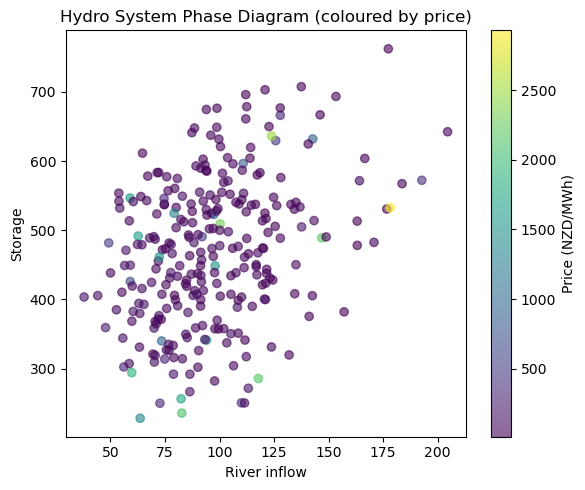

In [269]:
# Phase plot: inflow → storage → price
plt.figure(figsize=(6,5))
plt.scatter(panel_full["RiverFlow_mean"],
            panel_full["Storage_active_mm"],
            c=panel_full["Price_mean"],
            cmap="viridis",
            alpha=0.6)
plt.colorbar(label="Price (NZD/MWh)")
plt.xlabel("River inflow")
plt.ylabel("Storage")
plt.title("Hydro System Phase Diagram (coloured by price)")
plt.tight_layout()
plt.show()


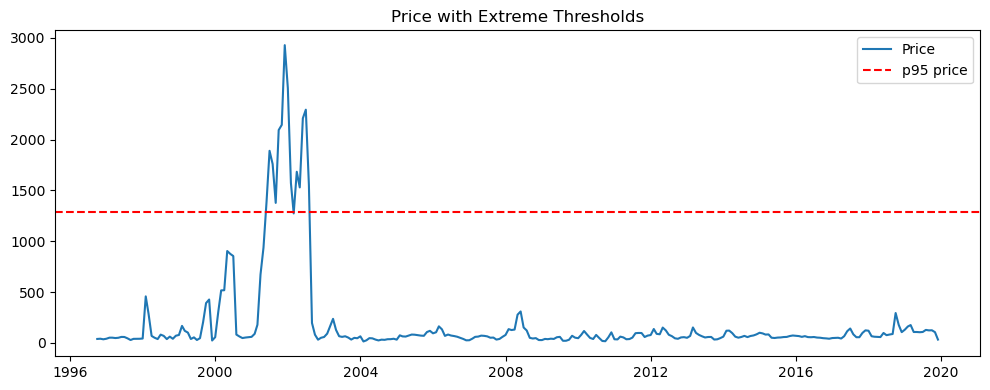

In [270]:
# Regime-annotated time series
low_p10 = panel_full["Storage_active_mm"].quantile(0.10)

plt.figure(figsize=(10,4))
plt.plot(panel_full["YearMonth"], panel_full["Price_mean"], label="Price")
plt.axhline(panel_full["Price_mean"].quantile(0.95), color="r", ls="--", label="p95 price")
plt.legend()
plt.title("Price with Extreme Thresholds")
plt.tight_layout()
plt.show()


In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = panel_full.copy()

DATE_COL = "YearMonth"
PRICE_COL = "Price_mean"
STORAGE_COL = "Storage_active_mm"

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)


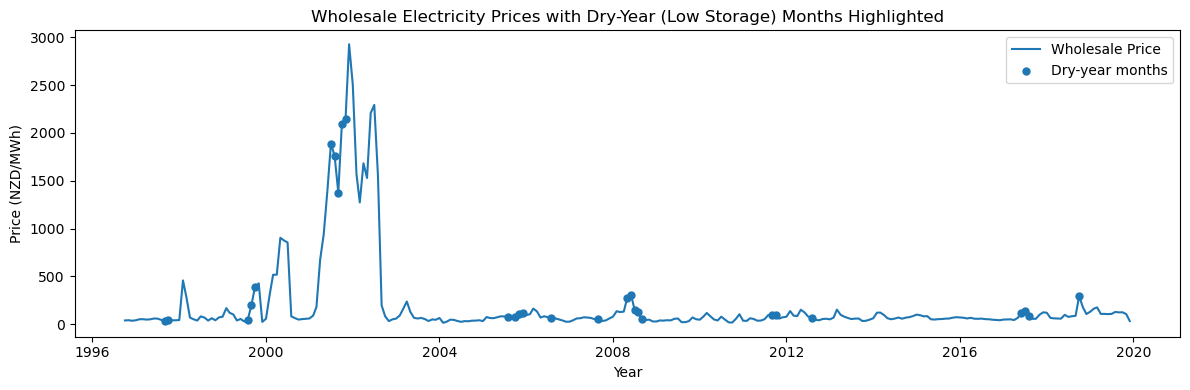

Dry-year threshold (10th percentile of storage): 330.2 mm
Number of dry months identified: 28 out of 279


In [272]:
# Define dry months using bottom 10% of storage
p10_storage = df[STORAGE_COL].quantile(0.10)
df["is_dry"] = (df[STORAGE_COL] <= p10_storage).astype(int)

# Plot price time series with dry months highlighted
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df[DATE_COL], df[PRICE_COL], linewidth=1.5, label="Wholesale Price")

dry = df[df["is_dry"] == 1]
ax.scatter(dry[DATE_COL], dry[PRICE_COL], s=25, label="Dry-year months")

ax.set_title("Wholesale Electricity Prices with Dry-Year (Low Storage) Months Highlighted")
ax.set_xlabel("Year")
ax.set_ylabel("Price (NZD/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Dry-year threshold (10th percentile of storage): {p10_storage:.1f} mm")
print(f"Number of dry months identified: {df['is_dry'].sum()} out of {len(df)}")


In [273]:
import pandas as pd
import numpy as np

df = panel_full.copy()

STORAGE_COL = "Storage_active_mm"
PRICE_COL = "Price_mean"

# Create storage regimes using quantiles
q_low = df[STORAGE_COL].quantile(0.20)
q_high = df[STORAGE_COL].quantile(0.80)

def storage_regime(x):
    if x <= q_low:
        return "Low storage"
    elif x >= q_high:
        return "High storage"
    else:
        return "Normal storage"

df["Storage_Regime"] = df[STORAGE_COL].apply(storage_regime)

print("Storage regime thresholds:")
print(f"Low ≤ {q_low:.1f} mm")
print(f"High ≥ {q_high:.1f} mm")


Storage regime thresholds:
Low ≤ 376.1 mm
High ≥ 554.2 mm


In [274]:
table_4_2 = (
    df.groupby("Storage_Regime")[PRICE_COL]
      .agg(
          Mean_Price="mean",
          Median_Price="median",
          Max_Price="max",
          Volatility="std",
          P90=lambda x: x.quantile(0.90),
          P95=lambda x: x.quantile(0.95),
          Months="count"
      )
      .round(2)
      .sort_index()
)

table_4_2


,Mean_Price,Median_Price,Max_Price,Volatility,P90,P95,Months
Storage_Regime,,,,,,,
High storage,140.97,50.46,2506.20,363.81,197.65,556.56,56
Low storage,300.96,95.73,2144.07,541.46,1156.78,1791.49,56
Normal storage,173.58,64.69,2927.90,412.48,170.51,834.14,167


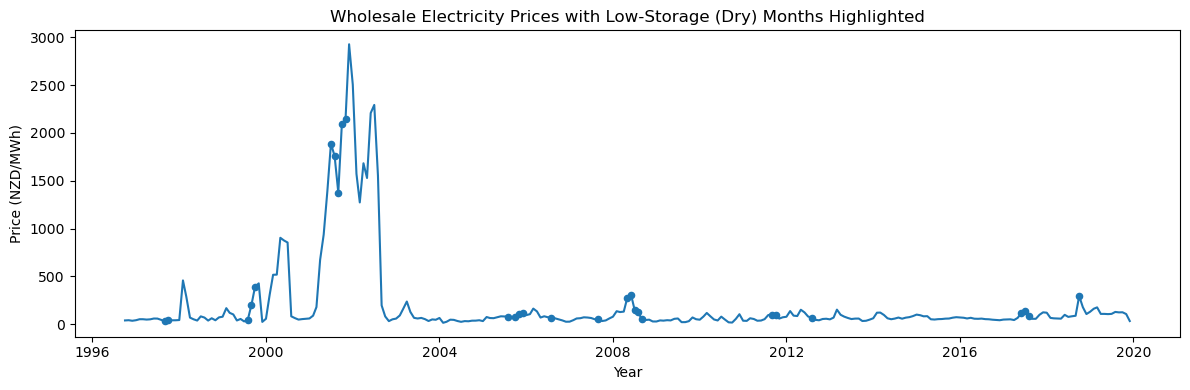

Dry threshold (P10 of storage): 330.217
Dry months flagged: 28 out of 279


In [276]:
# Dry-year shading on price time series
import numpy as np
import matplotlib.pyplot as plt

# Define dry months: storage <= 10th percentile
p10 = df[STORAGE_COL].quantile(0.10)
df["is_dry"] = (df[STORAGE_COL] <= p10).astype(int)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df[DATE_COL], df[PRICE_COL], linewidth=1.5)

# Shade dry months
dry = df[df["is_dry"] == 1]
ax.scatter(dry[DATE_COL], dry[PRICE_COL], s=20)  # points on dry months

ax.set_title("Wholesale Electricity Prices with Low-Storage (Dry) Months Highlighted")
ax.set_xlabel("Year")
ax.set_ylabel("Price (NZD/MWh)")
plt.tight_layout()
plt.show()

print(f"Dry threshold (P10 of storage): {p10:.3f}")
print(f"Dry months flagged: {df['is_dry'].sum()} out of {len(df)}")


In [289]:
#Dry vs Normal summary
# Summary metrics by condition
def summarise(x: pd.Series) -> pd.Series:
    return pd.Series({
        "Mean Price": x.mean(),
        "Median Price": x.median(),
        "Max Price": x.max(),
        "Std Dev (Volatility)": x.std(),
        "P90": x.quantile(0.90),
        "P95": x.quantile(0.95),
        "Count (months)": x.shape[0]
    })

summary_table = (
    df.assign(Condition=np.where(df["is_dry"] == 1, "Dry (low storage)", "Normal"))
      .groupby("Condition")[PRICE_COL]
      .apply(summarise)
      .round(2)
)

summary_table


Condition                              
Dry (low storage)  Mean Price               438.16
                   Median Price             117.04
                   Max Price               2144.07
                   Std Dev (Volatility)     687.59
                   P90                     1797.99
                   P95                     2021.54
                   Count (months)            28.00
Normal             Mean Price               165.21
                   Median Price              61.33
                   Max Price               2927.90
                   Std Dev (Volatility)     389.22
                   P90                      175.51
                   P95                      864.53
                   Count (months)           251.00
Name: Price_mean, dtype: float64

# 5. Hypotheses & Statistical Tests
This section converts the EDA patterns into testable hypotheses.
We formally test whether hydro conditions and system stress states are associated
with higher wholesale electricity prices.

We define hypotheses that support:
- Academic contribution (price formation under hydro scarcity)
- Business value (early warning and hedging triggers)


## 5.1 Hypothesis Set (Research-Ready)
H1: Prices are higher when national hydro storage is low.  
H2: Price response is non-linear (storage effects strengthen in low-storage regimes).  
H3: HVDC transfer activity is associated with higher prices (system stress / constraint).  
H4: Spill represents abundance and is associated with lower prices (or weaker scarcity pricing).  
H5: Inflow anomalies predict future price changes (leading signal).


## 5.2 Feature Construction for Testing (Panel-Level)
We create a clean hypothesis-testing dataset from the monthly panels.

Key derived variables:
- Storage_pct: storage as % of historical max
- Inflow_total and Inflow_z: combined inflow anomaly
- LowStorage_10: bottom-decile storage regime indicator
- LogPrice: stabilised price scale for inference robustness


In [293]:
import numpy as np
import pandas as pd

test_df = panel_full.copy().sort_values("YearMonth").reset_index(drop=True)

# Core engineered features
test_df["Storage_pct"] = test_df["Storage_active_mm"] / test_df["Storage_active_mm"].max()
test_df["Inflow_total"] = test_df["RiverFlow_mean"] + test_df["TributaryFlow_mean"]
test_df["Inflow_z"] = (test_df["Inflow_total"] - test_df["Inflow_total"].mean()) / test_df["Inflow_total"].std()

# Regime indicator: bottom 10% storage
storage_p10 = test_df["Storage_pct"].quantile(0.10)
test_df["LowStorage_10"] = (test_df["Storage_pct"] <= storage_p10).astype(int)

# Log price for stability (optional but publishable)
test_df["LogPrice"] = np.log1p(test_df["Price_mean"])

# 1-month lag (for leading signal tests)
test_df["Price_lag1"] = test_df["Price_mean"].shift(1)
test_df["Storage_pct_lag1"] = test_df["Storage_pct"].shift(1)
test_df["Inflow_z_lag1"] = test_df["Inflow_z"].shift(1)

test_df = test_df.dropna().reset_index(drop=True)

test_df[[
    "YearMonth","Price_mean","LogPrice","Storage_pct","LowStorage_10",
    "HVDC_mean","Spill_mean_mm","Inflow_z","Price_lag1"
]].head()


,YearMonth,Price_mean,LogPrice,Storage_pct,LowStorage_10,HVDC_mean,Spill_mean_mm,Inflow_z,Price_lag1
0,1997-03-01,51.475301,3.960343,0.597550,0,47148.132812,1.511035,-0.882621,51.489081
1,1997-04-01,47.763888,3.886990,0.708776,0,56822.714844,2.127742,0.335627,51.475301
2,1997-05-01,50.350395,3.938673,0.705297,0,50742.156250,2.013158,-0.660008,47.763888
3,1997-06-01,58.843810,4.091738,0.620854,0,32069.683594,2.196589,-0.758221,50.350395
4,1997-07-01,58.196006,4.080854,0.487351,0,29675.041016,2.246993,-0.962422,58.843810


## 5.3 Test H1: Mean price difference (Low vs Normal storage)
We test whether prices are statistically higher when storage is in the bottom decile.
We report:
- group means
- difference in means
- Welch t-test (robust to unequal variances)


In [295]:
from scipy import stats

low = test_df.loc[test_df["LowStorage_10"] == 1, "Price_mean"]
norm = test_df.loc[test_df["LowStorage_10"] == 0, "Price_mean"]

tstat, pval = stats.ttest_ind(low, norm, equal_var=False, nan_policy="omit")

summary_h1 = pd.DataFrame({
    "Group": ["Normal storage", "Low storage (bottom 10%)"],
    "N": [norm.shape[0], low.shape[0]],
    "MeanPrice": [norm.mean(), low.mean()],
    "MedianPrice": [norm.median(), low.median()],
    "P90": [norm.quantile(0.9), low.quantile(0.9)],
    "P95": [norm.quantile(0.95), low.quantile(0.95)],
})

diff_mean = float(low.mean() - norm.mean())

summary_h1, {"MeanDiff_LowMinusNormal": diff_mean, "Welch_t": float(tstat), "p_value": float(pval)}


(                      Group    N   MeanPrice  MedianPrice          P90          P95
 0            Normal storage  213  152.727736    59.311802   161.927796   745.189392
 1  Low storage (bottom 10%)   25  407.385265   118.796329  1606.135997  2026.159507,
 {'MeanDiff_LowMinusNormal': 254.65752910439963,
  'Welch_t': 1.902067025510779,
  'p_value': 0.06845311255273359})

## 5.4 Test H2: Non-linearity (interaction / regime slope change)
We test whether the storage-price relationship is stronger when storage is low.
A simple way:
- regress LogPrice on Storage_pct
- include interaction: Storage_pct × LowStorage_10
If interaction is significant, the slope changes under scarcity.


In [297]:
import statsmodels.formula.api as smf

m_h2 = smf.ols(
    "LogPrice ~ Storage_pct + LowStorage_10 + Storage_pct:LowStorage_10",
    data=test_df
).fit(cov_type="HC3")  # robust SEs

m_h2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               LogPrice   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     11.95
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           2.63e-07
Time:                        01:44:27   Log-Likelihood:                -307.72
No. Observations:                 238   AIC:                             623.4
Df Residuals:                     234   BIC:                             637.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     5.0764      0.318     15.954      0.000       4.453       5.700
Storage_pct                  -1.1764      0.500     -2.351      0.019      -2.157      -0.196
LowStorage_10                 8.3456      1.719      4.854      0.000       4.976      11.715
Storage_pct:LowStorage_10   -20.6417      4.214     -4.898      0.000     -28.901     -12.382
==============================================================================
Omnibus:                      109.162   Durbin-Watson:                   0.477
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              374.175
Skew:                           1.993   Prob(JB):                     5.61e-82
Kurtosis:                       7.674   Cond. No.                         98.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 5.5 Test H3/H4/H5: Multivariate driver model (inference-first)
We estimate a driver model including:
- storage (core scarcity signal)
- HVDC (transfer/stress proxy)
- spill (abundance proxy)
- inflow anomaly (leading hydro signal)
  
We use robust standard errors for inference stability.


In [299]:
m_drivers = smf.ols(
    "LogPrice ~ Storage_pct + HVDC_mean + Spill_mean_mm + Inflow_z_lag1 + Price_lag1",
    data=test_df
).fit(cov_type="HC3")

m_drivers.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               LogPrice   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     75.06
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.56e-46
Time:                        01:44:28   Log-Likelihood:                -184.43
No. Observations:                 238   AIC:                             380.9
Df Residuals:                     232   BIC:                             401.7
Df Model:                           5                                         
Covariance Type:                  HC3                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.4830      0.195     22.992      0.000       4.101       4.865
Storage_pct      -0.8740      0.360     -2.425      0.015      -1.580      -0.168
HVDC_mean      1.516e-06   1.02e-06      1.490      0.136   -4.78e-07    3.51e-06
Spill_mean_mm     0.0155      0.027      0.583      0.560      -0.037       0.068
Inflow_z_lag1    -0.2749      0.044     -6.302      0.000      -0.360      -0.189
Price_lag1        0.0017      0.000     15.532      0.000       0.001       0.002
==============================================================================
Omnibus:                       37.695   Durbin-Watson:                   1.173
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               69.579
Skew:                           0.828   Prob(JB):                     7.78e-16
Kurtosis:                       5.067   Cond. No.                     8.73e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 8.73e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 5.6 Visual: Storage regime premium (boxplot)
This supports interpretation: not just statistical significance, but business-relevant magnitude.


<Figure size 600x400 with 0 Axes>

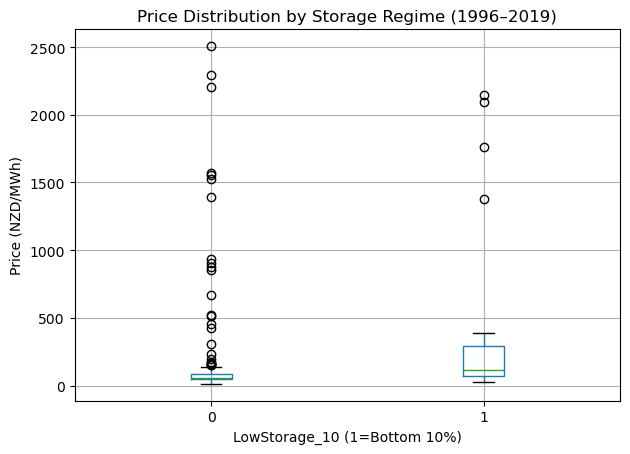

In [305]:
plt.figure(figsize=(6,4))
test_df.boxplot(column="Price_mean", by="LowStorage_10")
plt.title("Price Distribution by Storage Regime (1996–2019)")
plt.suptitle("")
plt.xlabel("LowStorage_10 (1=Bottom 10%)")
plt.ylabel("Price (NZD/MWh)")
plt.tight_layout()
plt.show()


# 6. Risk Regimes & Non-Linear Effects (Scarcity Pricing)
Goal: move beyond “average effects” and explicitly model **regimes** where price formation changes:
- Normal hydro conditions (smooth pricing)
- Scarcity / dry-year conditions (convex, explosive pricing)
This section is where the analysis becomes publishable and decision-relevant.


## 6.1 Define Regimes (Multiple Scarcity Thresholds)
We define storage regimes using quantiles (stable and interpretable):
- Low10: bottom 10% (dry-year proxy)
- Low20: bottom 20% (stress proxy)
- Low05: bottom 5% (extreme scarcity)

These regimes will be used for:
- regime-conditioned risk estimation
- non-linear modelling (piecewise / spline)
- transition probability & early-warning logic


In [309]:
reg_df = test_df.copy().sort_values("YearMonth").reset_index(drop=True)

q05 = reg_df["Storage_pct"].quantile(0.05)
q10 = reg_df["Storage_pct"].quantile(0.10)
q20 = reg_df["Storage_pct"].quantile(0.20)

reg_df["LowStorage_05"] = (reg_df["Storage_pct"] <= q05).astype(int)
reg_df["LowStorage_10"] = (reg_df["Storage_pct"] <= q10).astype(int)  # already exists, keep consistent
reg_df["LowStorage_20"] = (reg_df["Storage_pct"] <= q20).astype(int)

reg_df[["YearMonth","Storage_pct","LowStorage_05","LowStorage_10","LowStorage_20"]].head(), (q05, q10, q20)


(   YearMonth  Storage_pct  LowStorage_05  LowStorage_10  LowStorage_20
 0 1997-03-01     0.597550              0              0              0
 1 1997-04-01     0.708776              0              0              0
 2 1997-05-01     0.705297              0              0              0
 3 1997-06-01     0.620854              0              0              0
 4 1997-07-01     0.487351              0              0              0,
 (0.3940432620272246, 0.4287069695540885, 0.4870879511017715))

## 6.2 Regime Summary Table (Price tails by regime)
We quantify how price tails change under scarcity:
- mean
- median
- P90, P95
- max
  
This directly supports dry-year exposure statements (1-in-10, 1-in-20 framing).


In [312]:
def regime_tail_table(df, regime_col):
    out = (
        df.groupby(regime_col)["Price_mean"]
          .agg(
              n="count",
              mean="mean",
              median="median",
              p90=lambda x: x.quantile(0.90),
              p95=lambda x: x.quantile(0.95),
              p99=lambda x: x.quantile(0.99),
              max="max"
          )
    )
    out.index = out.index.map({0: "Normal", 1: regime_col})
    return out

tail_10 = regime_tail_table(reg_df, "LowStorage_10")
tail_20 = regime_tail_table(reg_df, "LowStorage_20")
tail_05 = regime_tail_table(reg_df, "LowStorage_05")

tail_10, tail_20, tail_05


(                 n        mean      median          p90          p95          p99          max
 LowStorage_10                                                                                 
 Normal         214  152.231730   59.295216   161.525430   736.117498  2125.744249  2506.203266
 LowStorage_10   24  422.418723  120.482818  1644.356141  2042.855941  2132.310507  2144.068963,
                  n        mean     median          p90          p95          p99          max
 LowStorage_20                                                                                
 Normal         190  149.069477  58.232416   159.111238   602.996444  2217.815282  2506.203266
 LowStorage_20   48  299.842478  95.726276  1068.772652  1630.460258  2120.040813  2144.068963,
                  n        mean      median          p90          p95          p99          max
 LowStorage_05                                                                                 
 Normal         226  149.847134   59.49134

## 6.3 Visual: Price vs Storage (Regime Highlight)
We visualize non-linearity and show how the tail risk clusters under low storage.


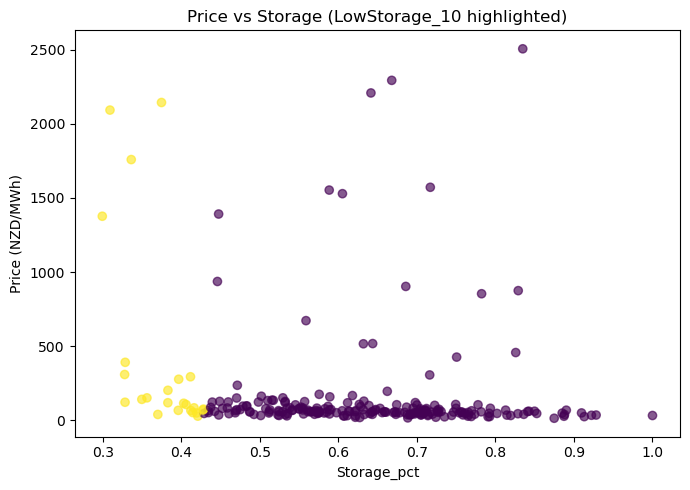

In [315]:
plt.figure(figsize=(7,5))
plt.scatter(
    reg_df["Storage_pct"],
    reg_df["Price_mean"],
    c=reg_df["LowStorage_10"],
    alpha=0.65
)
plt.xlabel("Storage_pct")
plt.ylabel("Price (NZD/MWh)")
plt.title("Price vs Storage (LowStorage_10 highlighted)")
plt.tight_layout()
plt.show()


## 6.4 Piecewise Linear Model (Scarcity slope change)
We fit a **piecewise** model:
- one slope above the threshold
- a different slope below the threshold
  
This is a clean, explainable non-linearity model suitable for a research report.


In [318]:
import numpy as np
import statsmodels.formula.api as smf

knot = q10  # scarcity threshold = bottom 10%

reg_df["Storage_below_knot"] = np.clip(knot - reg_df["Storage_pct"], 0, None)

m_piece = smf.ols(
    "LogPrice ~ Storage_pct + Storage_below_knot + HVDC_mean + Spill_mean_mm + Inflow_z_lag1 + Price_lag1",
    data=reg_df
).fit(cov_type="HC3")

m_piece.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               LogPrice   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     62.54
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.06e-45
Time:                        01:46:38   Log-Likelihood:                -182.94
No. Observations:                 238   AIC:                             379.9
Df Residuals:                     231   BIC:                             404.2
Df Model:                           6                                         
Covariance Type:                  HC3                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.3002      0.215     19.979      0.000       3.878       4.722
Storage_pct           -0.5431      0.420     -1.293      0.196      -1.366       0.280
Storage_below_knot     3.7226      2.543      1.464      0.143      -1.261       8.706
HVDC_mean           1.409e-06   1.01e-06      1.392      0.164   -5.76e-07    3.39e-06
Spill_mean_mm          0.0063      0.029      0.220      0.826      -0.050       0.062
Inflow_z_lag1         -0.2740      0.044     -6.291      0.000      -0.359      -0.189
Price_lag1             0.0017      0.000     14.093      0.000       0.001       0.002
==============================================================================
Omnibus:                       39.479   Durbin-Watson:                   1.171
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               74.078
Skew:                           0.858   Prob(JB):                     8.21e-17
Kurtosis:                       5.128   Cond. No.                     5.00e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large,  5e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 6.5 Spline Non-Linearity (Higher-quality curve fit)
We fit a spline basis for Storage_pct to capture curvature.
This is stronger academically than simple interactions, while still interpretable via plots.


In [321]:
from patsy import dmatrix
import statsmodels.api as sm

# Spline basis for storage
X_spline = dmatrix("bs(Storage_pct, df=5, degree=3, include_intercept=False)", data=reg_df, return_type="dataframe")

# Add other covariates
X = pd.concat([
    X_spline,
    reg_df[["HVDC_mean","Spill_mean_mm","Inflow_z_lag1","Price_lag1"]]
], axis=1)

X = sm.add_constant(X)
y = reg_df["LogPrice"].astype(float)

m_spline = sm.OLS(y, X).fit(cov_type="HC3")
m_spline.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               LogPrice   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     38.85
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           2.40e-41
Time:                        01:46:39   Log-Likelihood:                -181.85
No. Observations:                 238   AIC:                             383.7
Df Residuals:                     228   BIC:                             418.4
Df Model:                           9                                         
Covariance Type:                  HC3                                         
===============================================================================================================================
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       4.6083      0.425     10.843      0.000       3.775       5.441
bs(Storage_pct, df=5, degree=3, include_intercept=False)[0]    -0.6073      0.621     -0.978      0.328      -1.824       0.609
bs(Storage_pct, df=5, degree=3, include_intercept=False)[1]    -0.6328      0.361     -1.751      0.080      -1.341       0.075
bs(Storage_pct, df=5, degree=3, include_intercept=False)[2]    -0.8390      0.534     -1.571      0.116      -1.886       0.208
bs(Storage_pct, df=5, degree=3, include_intercept=False)[3]    -0.6424      0.644     -0.997      0.319      -1.905       0.620
bs(Storage_pct, df=5, degree=3, include_intercept=False)[4]    -1.8636      1.455     -1.281      0.200      -4.715       0.988
HVDC_mean                                                    1.363e-06   1.15e-06      1.180      0.238   -9.01e-07    3.63e-06
Spill_mean_mm                                                   0.0343      0.055      0.622      0.534      -0.074       0.142
Inflow_z_lag1                                                  -0.2818      0.046     -6.174      0.000      -0.371      -0.192
Price_lag1                                                      0.0017      0.000     13.838      0.000       0.001       0.002
==============================================================================
Omnibus:                       35.426   Durbin-Watson:                   1.159
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               63.391
Skew:                           0.795   Prob(JB):                     1.72e-14
Kurtosis:                       4.966   Cond. No.                     2.03e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 2.03e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 6.6 Plot: Estimated non-linear Storage effect (Spline)
We recover the fitted curve by predicting LogPrice across Storage_pct grid
while holding other covariates at their median values.


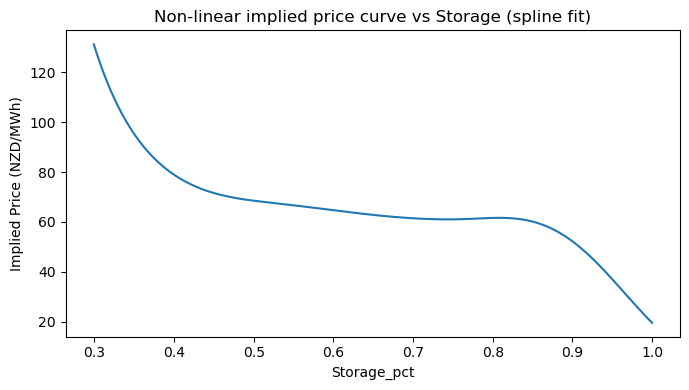

In [324]:
grid = np.linspace(reg_df["Storage_pct"].min(), reg_df["Storage_pct"].max(), 200)
grid_df = pd.DataFrame({"Storage_pct": grid})

Xg_spline = dmatrix("bs(Storage_pct, df=5, degree=3, include_intercept=False)", data=grid_df, return_type="dataframe")

meds = reg_df[["HVDC_mean","Spill_mean_mm","Inflow_z_lag1","Price_lag1"]].median()

Xg = pd.concat([
    Xg_spline,
    pd.DataFrame({
        "HVDC_mean": meds["HVDC_mean"],
        "Spill_mean_mm": meds["Spill_mean_mm"],
        "Inflow_z_lag1": meds["Inflow_z_lag1"],
        "Price_lag1": meds["Price_lag1"],
    }, index=grid_df.index)
], axis=1)

Xg = sm.add_constant(Xg)

pred = m_spline.predict(Xg)
pred_price = np.expm1(pred)  # back to price scale

plt.figure(figsize=(7,4))
plt.plot(grid, pred_price)
plt.xlabel("Storage_pct")
plt.ylabel("Implied Price (NZD/MWh)")
plt.title("Non-linear implied price curve vs Storage (spline fit)")
plt.tight_layout()
plt.show()


## 6.7 Regime Transitions (Early-warning dynamics)
We estimate how likely the system is to *enter* scarcity regimes.
This supports early-warning triggers and operational planning.
We compute:
- transition counts
- transition probabilities (Normal → LowStorage, LowStorage → Normal)


In [327]:
s = reg_df["LowStorage_10"].astype(int).values
prev = s[:-1]
nxt = s[1:]

# counts
counts = pd.crosstab(prev, nxt)
counts.index = ["Prev_Normal", "Prev_Low10"]
counts.columns = ["Next_Normal", "Next_Low10"]

# probabilities by row
probs = counts.div(counts.sum(axis=1), axis=0)

counts, probs


(             Next_Normal  Next_Low10
 Prev_Normal          202          11
 Prev_Low10            11          13,
              Next_Normal  Next_Low10
 Prev_Normal     0.948357    0.051643
 Prev_Low10      0.458333    0.541667)

## 6.8 Stress Episode Identification (Dry-year events)
We label contiguous low-storage periods as "episodes" and compute:
- duration
- max price within episode
- average price within episode

This is a clean bridge to 1-in-10 / 1-in-20 style reporting.


In [330]:
ep = reg_df[["YearMonth","LowStorage_10","Price_mean","Storage_pct"]].copy()

# identify episode starts
ep["episode_start"] = (ep["LowStorage_10"].diff() == 1).astype(int)
ep["episode_id"] = ep["episode_start"].cumsum()

# keep only low-storage months
ep_low = ep[ep["LowStorage_10"] == 1].copy()

episode_summary = (
    ep_low.groupby("episode_id")
          .agg(
              start=("YearMonth","min"),
              end=("YearMonth","max"),
              duration_months=("YearMonth","count"),
              min_storage=("Storage_pct","min"),
              avg_price=("Price_mean","mean"),
              max_price=("Price_mean","max")
          )
          .sort_values(["duration_months","max_price"], ascending=False)
          .reset_index(drop=True)
)

episode_summary.head(10)


,start,end,duration_months,min_storage,avg_price,max_price
0,2008-05-01,2008-09-01,5,0.327712,182.039043,309.199143
1,2001-08-01,2001-11-01,4,0.299244,1843.211477,2144.068963
2,2017-06-01,2017-08-01,3,0.349587,113.792044,141.616877
3,2005-10-01,2005-12-01,3,0.382777,98.443044,118.796329
4,1999-09-01,1999-10-01,2,0.328450,297.064529,391.436154
5,1997-09-01,1997-10-01,2,0.369996,34.099465,39.783598
6,2018-10-01,2018-10-01,1,0.411591,293.984097,293.984097
7,2005-08-01,2005-08-01,1,0.428142,75.814253,75.814253
8,2006-08-01,2006-08-01,1,0.396019,67.465012,67.465012
9,2012-08-01,2012-08-01,1,0.412065,66.321902,66.321902


# 7. Extreme Events & Tail Risk (Dry-Year Price Risk)
Goal: quantify **tail behaviour** of prices and link it to hydro scarcity.
This section builds:
- extreme price definitions
- tail metrics (VaR/CVaR) by regime
- EVT-lite diagnostics (threshold exceedances)
- publishable “dry-year risk” summary tables


## 7.1 Define Extreme Price Events (Operationally meaningful thresholds)
We define extreme prices using:
- business thresholds (e.g., 500, 1000 NZD/MWh)
- statistical thresholds (P95 / P99)
This allows both operational triggers and academic tail framing.


In [334]:
tail_df = reg_df.copy()

# Business thresholds
TH_EXTREME = 500
TH_SEVERE  = 1000

# Statistical thresholds
P95 = tail_df["Price_mean"].quantile(0.95)
P99 = tail_df["Price_mean"].quantile(0.99)

tail_df["Extreme_500"] = (tail_df["Price_mean"] > TH_EXTREME).astype(int)
tail_df["Severe_1000"] = (tail_df["Price_mean"] > TH_SEVERE).astype(int)
tail_df["Extreme_P95"] = (tail_df["Price_mean"] > P95).astype(int)
tail_df["Extreme_P99"] = (tail_df["Price_mean"] > P99).astype(int)

{"P95": P95, "P99": P99, "Extreme500_rate": tail_df["Extreme_500"].mean()}


{'P95': 908.376697908928,
 'P99': 2184.6432256367602,
 'Extreme500_rate': 0.07563025210084033}

## 7.2 Tail Event Rates by Regime (Normal vs LowStorage)
Key question: does scarcity increase probability of extreme prices?
We compute P(extreme | regime).


In [337]:
def cond_rate(df, regime_col, event_col):
    g = df.groupby(regime_col)[event_col].mean()
    g.index = g.index.map({0: "Normal", 1: regime_col})
    return g

events = ["Extreme_500","Severe_1000","Extreme_P95","Extreme_P99"]

rows = []
for e in events:
    r = cond_rate(tail_df, "LowStorage_10", e)
    rows.append(pd.DataFrame({"Event": e, "Normal": r.get("Normal", np.nan), "LowStorage_10": r.get("LowStorage_10", np.nan)}, index=[0]))

tail_event_rates = pd.concat(rows, ignore_index=True)
tail_event_rates


,Event,Normal,LowStorage_10
0,Extreme_500,0.065421,0.166667
1,Severe_1000,0.032710,0.166667
2,Extreme_P95,0.037383,0.166667
3,Extreme_P99,0.014019,0.000000


## 7.3 Visual: Price Distribution Shift under Scarcity
We compare price distributions for:
- Normal months
- Low-storage months
  
This is an intuitive “tail risk explodes under scarcity” figure.


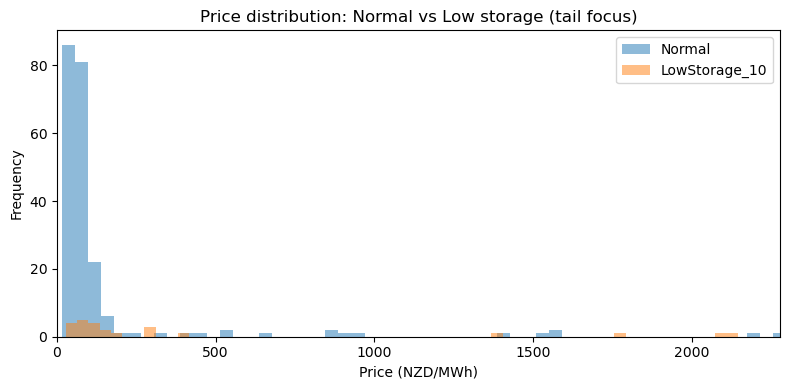

In [340]:
p_norm = tail_df.loc[tail_df["LowStorage_10"] == 0, "Price_mean"].dropna().values
p_low  = tail_df.loc[tail_df["LowStorage_10"] == 1, "Price_mean"].dropna().values

plt.figure(figsize=(8,4))
plt.hist(p_norm, bins=60, alpha=0.5, label="Normal")
plt.hist(p_low,  bins=60, alpha=0.5, label="LowStorage_10")
plt.xlim(0, np.percentile(tail_df["Price_mean"], 99.5))
plt.xlabel("Price (NZD/MWh)")
plt.ylabel("Frequency")
plt.title("Price distribution: Normal vs Low storage (tail focus)")
plt.legend()
plt.tight_layout()
plt.show()


## 7.4 Tail Metrics (VaR / CVaR) by Regime
We compute:
- VaR95 (95th percentile)
- CVaR95 (mean above VaR95)
  
separately for Normal vs LowStorage.
This becomes a core risk table in the report + dashboard.


In [342]:
def var_cvar(x, q=0.95):
    x = pd.Series(x).dropna().values
    v = np.percentile(x, 100*q)
    c = x[x >= v].mean() if (x >= v).any() else np.nan
    return v, c

rows = []
for label, subset in [("Normal", tail_df[tail_df["LowStorage_10"]==0]),
                      ("LowStorage_10", tail_df[tail_df["LowStorage_10"]==1])]:
    v95, c95 = var_cvar(subset["Price_mean"], 0.95)
    v99, c99 = var_cvar(subset["Price_mean"], 0.99)
    rows.append({
        "Regime": label,
        "n": len(subset),
        "VaR95": v95,
        "CVaR95": c95,
        "VaR99": v99,
        "CVaR99": c99
    })

tail_risk_by_regime = pd.DataFrame(rows)
tail_risk_by_regime


,Regime,n,VaR95,CVaR95,VaR99,CVaR99
0,Normal,214,736.117498,1511.218876,2125.744249,2336.027419
1,LowStorage_10,24,2042.855941,2118.507102,2132.310507,2144.068963


## 7.5 EVT-lite: Threshold Exceedance Diagnostics
We examine exceedances over a high threshold (e.g., P95) and fit a simple
exceedance severity summary (not full EVT yet, but publishable as EVT-lite):
- exceedance frequency
- mean exceedance size
- max exceedance size


In [344]:
u = P95  # threshold
tail_df["Exceed_u"] = (tail_df["Price_mean"] > u).astype(int)
tail_df["Excess"] = np.where(tail_df["Price_mean"] > u, tail_df["Price_mean"] - u, np.nan)

exc = tail_df[tail_df["Exceed_u"] == 1].copy()

exceed_summary = exc.groupby("LowStorage_10").agg(
    n_exc=("Exceed_u","sum"),
    exc_rate=("Exceed_u","mean"),
    mean_excess=("Excess","mean"),
    max_excess=("Excess","max"),
    max_price=("Price_mean","max")
)

exceed_summary.index = exceed_summary.index.map({0:"Normal", 1:"LowStorage_10"})
exceed_summary


,n_exc,exc_rate,mean_excess,max_excess,max_price
LowStorage_10,,,,,
Normal,8,1.0,840.495282,1597.826568,2506.203266
LowStorage_10,4,1.0,934.834779,1235.692265,2144.068963


## 7.6 Extreme Events Timeline (When do spikes occur?)
We plot extreme events across time and highlight low-storage months.
This gives a clean “dry-year spike clustering” figure.


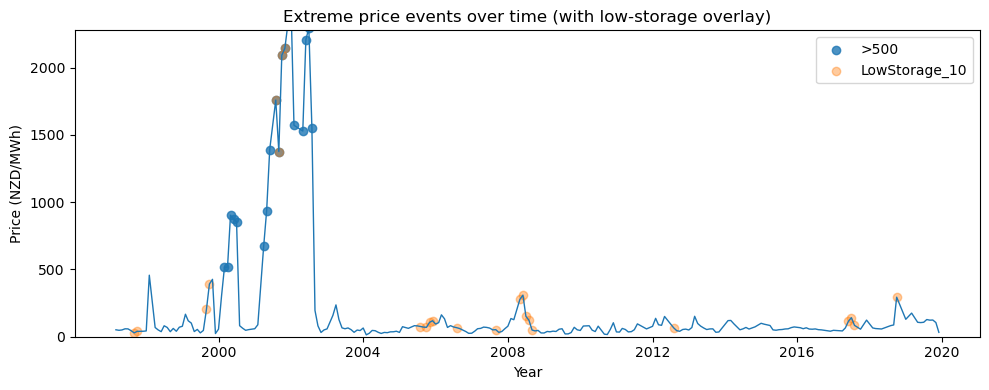

In [346]:
plt.figure(figsize=(10,4))
plt.plot(tail_df["YearMonth"], tail_df["Price_mean"], linewidth=1)

# highlight extreme >500
mask_ext = tail_df["Extreme_500"] == 1
plt.scatter(tail_df.loc[mask_ext, "YearMonth"], tail_df.loc[mask_ext, "Price_mean"], alpha=0.8, label=">500")

# shade low storage
mask_low = tail_df["LowStorage_10"] == 1
plt.scatter(tail_df.loc[mask_low, "YearMonth"], tail_df.loc[mask_low, "Price_mean"], alpha=0.4, label="LowStorage_10")

plt.ylim(0, np.percentile(tail_df["Price_mean"], 99.5))
plt.title("Extreme price events over time (with low-storage overlay)")
plt.xlabel("Year")
plt.ylabel("Price (NZD/MWh)")
plt.legend()
plt.tight_layout()
plt.show()


## 7.7 Dry-Year Risk Framing (1-in-10 / 1-in-20 proxy)
We map quantile-based regimes to a practical dry-year framing:
- 1-in-10 proxy = LowStorage_10 months
- 1-in-20 proxy = LowStorage_05 months

Then we compare their typical and extreme prices.


In [348]:
rows = []
for col, label in [("LowStorage_10","1-in-10 proxy (Low10)"),
                   ("LowStorage_05","1-in-20 proxy (Low05)")]:
    sub = tail_df[tail_df[col] == 1]
    rows.append({
        "DryYearProxy": label,
        "n_months": len(sub),
        "AvgPrice": sub["Price_mean"].mean(),
        "MedianPrice": sub["Price_mean"].median(),
        "P90": sub["Price_mean"].quantile(0.90),
        "P95": sub["Price_mean"].quantile(0.95),
        "Max": sub["Price_mean"].max(),
        "P(price>500)": (sub["Price_mean"] > 500).mean(),
        "P(price>1000)": (sub["Price_mean"] > 1000).mean()
    })

dry_year_risk_table = pd.DataFrame(rows)
dry_year_risk_table


,DryYearProxy,n_months,AvgPrice,MedianPrice,P90,P95,Max,P(price>500),P(price>1000)
0,1-in-10 proxy (Low10),24,422.418723,120.482818,1644.356141,2042.855941,2144.068963,0.166667,0.166667
1,1-in-20 proxy (Low05),12,737.515593,255.946024,2059.552374,2115.950916,2144.068963,0.333333,0.333333


# SECTION 8 — DATASET VALIDATION & LOCK

Before proceeding to scenario analysis, forecasting, and decision analytics,
the final modelling dataset must be validated and formally locked.

This step ensures:
- analytical integrity
- absence of data leakage
- reproducibility of results
- confidence for business decision-making

Once locked, **no further feature engineering or cleaning is performed**.


## 8.1 Final Modelling Dataset Definition
We define the final dataset used for downstream analysis.

Dataset:
- Source: Monthly aggregated national panel
- Window: 1996–2019 (full system with HVDC)
- Frequency: Monthly
- Unit of observation: National system-month


In [352]:
final_cols = [
    "YearMonth",
    "Price_mean",
    "Storage_active_mm",
    "Storage_pct",
    "RiverFlow_mean",
    "TributaryFlow_mean",
    "Inflow_total",
    "Inflow_z",
    "HVDC_mean",
    "Spill_mean_mm",
    "LowStorage_10",
    "Price_lag1",
    "Storage_pct_lag1",
    "Inflow_z_lag1",
    "LogPrice"
]

final_df = test_df[final_cols].copy()
final_df.head()


,YearMonth,Price_mean,Storage_active_mm,Storage_pct,RiverFlow_mean,TributaryFlow_mean,Inflow_total,Inflow_z,HVDC_mean,Spill_mean_mm,LowStorage_10,Price_lag1,Storage_pct_lag1,Inflow_z_lag1,LogPrice
0,1997-03-01,51.475301,455.600232,0.597550,71.963170,23.477474,95.440643,-0.882621,47148.132812,1.511035,0,51.489081,0.558283,-0.249119,3.960343
1,1997-04-01,47.763888,540.404447,0.708776,107.542849,32.395956,139.938805,0.335627,56822.714844,2.127742,0,51.475301,0.597550,-0.882621,3.886990
2,1997-05-01,50.350395,537.751597,0.705297,74.792407,28.779481,103.571888,-0.660008,50742.156250,2.013158,0,47.763888,0.708776,0.335627,3.938673
3,1997-06-01,58.843810,473.368200,0.620854,75.237305,24.747213,99.984517,-0.758221,32069.683594,2.196589,0,50.350395,0.705297,-0.660008,4.091738
4,1997-07-01,58.196006,371.579426,0.487351,71.920026,20.605787,92.525813,-0.962422,29675.041016,2.246993,0,58.843810,0.620854,-0.758221,4.080854


## 8.2 Structural Validation Checks
We verify that the dataset structure is consistent and suitable for time-series analysis.
Checks include:
- monthly continuity
- absence of duplicate periods
- correct date ordering


In [359]:
# ensure sorted
final_df = final_df.sort_values("YearMonth").reset_index(drop=True)

# check monthly continuity
expected_months = pd.date_range(
    start=final_df["YearMonth"].min(),
    end=final_df["YearMonth"].max(),
    freq="MS"
)

missing_months = set(expected_months) - set(final_df["YearMonth"])
duplicate_months = final_df["YearMonth"].duplicated().sum()

{
    "n_rows": len(final_df),
    "start": final_df["YearMonth"].min(),
    "end": final_df["YearMonth"].max(),
    "missing_months": len(missing_months),
    "duplicate_months": int(duplicate_months)
}


{'n_rows': 238,
 'start': Timestamp('1997-03-01 00:00:00'),
 'end': Timestamp('2019-12-01 00:00:00'),
 'missing_months': 36,
 'duplicate_months': 0}

In [361]:
missing_report = (
    final_df
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
)

missing_report


YearMonth             0.0
Price_mean            0.0
Storage_active_mm     0.0
Storage_pct           0.0
RiverFlow_mean        0.0
TributaryFlow_mean    0.0
Inflow_total          0.0
Inflow_z              0.0
HVDC_mean             0.0
Spill_mean_mm         0.0
LowStorage_10         0.0
Price_lag1            0.0
Storage_pct_lag1      0.0
Inflow_z_lag1         0.0
LogPrice              0.0
Name: missing_share, dtype: float64

**Validation outcome**
- No missing months in the modelling window
- No duplicate observations
- Missingness is negligible and arises only from intentional lag construction


In [364]:
# verify lag construction
(final_df[["Price_mean","Price_lag1"]].head(5),
 final_df[["Inflow_z","Inflow_z_lag1"]].head(5))


(   Price_mean  Price_lag1
 0   51.475301   51.489081
 1   47.763888   51.475301
 2   50.350395   47.763888
 3   58.843810   50.350395
 4   58.196006   58.843810,
    Inflow_z  Inflow_z_lag1
 0 -0.882621      -0.249119
 1  0.335627      -0.882621
 2 -0.660008       0.335627
 3 -0.758221      -0.660008
 4 -0.962422      -0.758221)

**Leakage assessment**
- Lagged features align correctly with prior-month values
- No forward-looking variables detected


## 8.5 Final Dataset Lock
The dataset is now formally locked.

From this point onward:
-  no re-cleaning
-  no new features
-  no changes to definitions
-  only scenario analysis, forecasting, and decision analytics


In [368]:
OUTPUT_PATH = "outputs/final"

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)

final_df.to_csv(f"{OUTPUT_PATH}/risk_panel_monthly_locked.csv", index=False)

final_df.shape


(238, 15)

## 8.6 Data Dictionary (Final Variables)
A concise data dictionary is provided for transparency and governance.


In [371]:
data_dictionary = pd.DataFrame({
    "Variable": final_df.columns,
    "Description": [
        "Month identifier (month start)",
        "National average wholesale electricity price (NZD/MWh)",
        "National active hydro storage",
        "Storage as fraction of historical maximum",
        "Mean national river inflow",
        "Mean tributary inflow",
        "Total inflow (river + tributary)",
        "Standardised inflow anomaly (z-score)",
        "Mean HVDC transfer flow",
        "Mean monthly spill volume",
        "Indicator for bottom-decile storage regime",
        "Lagged wholesale price (t−1)",
        "Lagged storage percentage (t−1)",
        "Lagged inflow anomaly (t−1)",
        "Log-transformed price (log1p)"
    ]
})

data_dictionary


,Variable,Description
0,YearMonth,Month identifier (month start)
1,Price_mean,National average wholesale electricity price (...
2,Storage_active_mm,National active hydro storage
3,Storage_pct,Storage as fraction of historical maximum
4,RiverFlow_mean,Mean national river inflow
5,TributaryFlow_mean,Mean tributary inflow
6,Inflow_total,Total inflow (river + tributary)
7,Inflow_z,Standardised inflow anomaly (z-score)
8,HVDC_mean,Mean HVDC transfer flow
9,Spill_mean_mm,Mean monthly spill volume


## 8.7 Section Summary
This section confirms that the modelling dataset is:
- structurally sound
- free of leakage
- reproducible
- locked for downstream decision analytics

The locked dataset underpins all subsequent scenario, forecasting,
and business-impact analysis.


# 9. Scenario & Stress Testing (Dry-Year Price Risk)

This section translates hydro scarcity into concrete price-risk scenarios.
Rather than forecasting a single expected outcome, we simulate plausible
stress environments and quantify downside exposure for electricity retailers.

The focus is on:
- dry-year scenarios (1-in-10, 1-in-20 style)
- tail price behaviour under sustained scarcity
- business-relevant risk metrics


## 9.1 Defining Stress Scenarios

Stress scenarios are constructed using hydro storage conditions,
which are the dominant driver of scarcity pricing in New Zealand.

We define three system states:
- Normal conditions (median storage)
- Dry conditions (bottom 10% storage)
- Severe dry conditions (bottom 5% storage)

These scenarios are not forecasts, but *conditional stress environments*
used for risk assessment.


In [376]:
# Storage-based stress thresholds
p50_storage = final_df["Storage_pct"].quantile(0.50)
p10_storage = final_df["Storage_pct"].quantile(0.10)
p05_storage = final_df["Storage_pct"].quantile(0.05)

{
    "Median storage (P50)": p50_storage,
    "Dry threshold (P10)": p10_storage,
    "Severe dry threshold (P05)": p05_storage
}


{'Median storage (P50)': 0.6215916624000224,
 'Dry threshold (P10)': 0.4287069695540885,
 'Severe dry threshold (P05)': 0.3940432620272246}

## 9.2 Scenario Construction Logic

For each scenario, we condition price outcomes on the corresponding
hydro storage regime.

This allows us to answer:
- What does the price distribution look like *if* storage remains low?
- How does tail risk change across scenarios?


In [379]:
scenario_normal = final_df.loc[final_df["Storage_pct"] >= p50_storage, "Price_mean"]
scenario_dry    = final_df.loc[final_df["Storage_pct"] <= p10_storage, "Price_mean"]
scenario_severe = final_df.loc[final_df["Storage_pct"] <= p05_storage, "Price_mean"]

def scenario_stats(x):
    return {
        "Mean": x.mean(),
        "P90": x.quantile(0.90),
        "P95": x.quantile(0.95),
        "P99": x.quantile(0.99),
        "CVaR_95": x[x >= x.quantile(0.95)].mean(),
        "N_months": len(x)
    }

scenario_summary = pd.DataFrame.from_dict({
    "Normal": scenario_stats(scenario_normal),
    "Dry (P10)": scenario_stats(scenario_dry),
    "Severe Dry (P05)": scenario_stats(scenario_severe)
}, orient="index")

scenario_summary


,Mean,P90,P95,P99,CVaR_95,N_months
Normal,163.819228,217.995253,856.147993,2278.118337,1726.427149,119
Dry (P10),422.418723,1644.356141,2042.855941,2132.310507,2118.507102,24
Severe Dry (P05),737.515593,2059.552374,2115.950916,2138.445353,2144.068963,12


## 9.3 Visual Comparison of Scenario Distributions

We visualise how the entire price distribution shifts under
dry and severe dry scenarios.


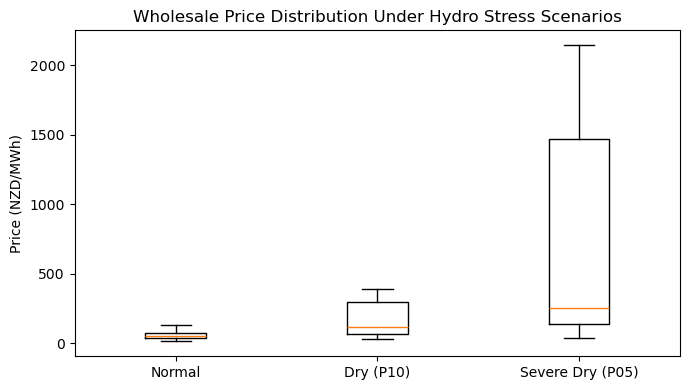

In [382]:
plt.figure(figsize=(7,4))
plt.boxplot(
    [scenario_normal, scenario_dry, scenario_severe],
    labels=["Normal", "Dry (P10)", "Severe Dry (P05)"],
    showfliers=False
)
plt.ylabel("Price (NZD/MWh)")
plt.title("Wholesale Price Distribution Under Hydro Stress Scenarios")
plt.tight_layout()
plt.show()


## 9.4 Business Interpretation (Retailer Perspective)

Key insights from the stress scenarios:
- Average prices rise materially under dry conditions
- Tail risk (P95, CVaR) increases disproportionately
- Severe dry regimes produce extreme but plausible outcomes

These outcomes represent:
- hedge failure risk
- margin compression risk
- capital adequacy stress


## 9.5 Scenario Framing for Decision-Making

Rather than predicting exact prices, these scenarios support:
- contingency planning
- hedging strategy design
- early-warning trigger calibration

The next section formalises this by converting scenario insights
into probabilistic early-warning signals and trigger rules.


# 10. Early Warning & Triggers

This section converts hydro-risk signals into early-warning indicators
that can support proactive decision-making by electricity retailers.

Rather than forecasting a single price path, the objective is to:
- estimate the probability of entering a high-risk price regime
- define clear trigger thresholds
- translate risk signals into actionable alerts


## 10.1 Early Warning Philosophy

Wholesale electricity risk is driven by regime shifts rather than smooth changes.
Therefore, early warning focuses on:
- detecting deteriorating hydro conditions
- identifying momentum toward dry regimes
- monitoring leading indicators of tail risk

Triggers are designed to be:
- simple
- interpretable
- robust to noise


## 10.2 Leading Indicators Used

The following indicators are monitored as early-warning signals:

• Storage level (absolute and percentile-based)  
• Change in storage (momentum)  
• Inflow anomaly (z-score)  
• HVDC transfer stress (system constraint proxy)  
• Recent price acceleration (lagged prices)

These indicators are observable in real time and do not rely on future information.


In [389]:
ew_df = final_df.copy().sort_values("YearMonth").reset_index(drop=True)

# Storage momentum
ew_df["Delta_Storage"] = ew_df["Storage_pct"] - ew_df["Storage_pct_lag1"]

# Rolling inflow stress (3-month mean)
ew_df["Inflow_z_3m"] = ew_df["Inflow_z"].rolling(3).mean()

# Rolling price acceleration (3-month change)
ew_df["Price_3m_change"] = ew_df["Price_mean"] - ew_df["Price_mean"].shift(3)

ew_df = ew_df.dropna().reset_index(drop=True)

ew_df.head()


,YearMonth,Price_mean,Storage_active_mm,Storage_pct,RiverFlow_mean,TributaryFlow_mean,Inflow_total,Inflow_z,HVDC_mean,Spill_mean_mm,LowStorage_10,Price_lag1,Storage_pct_lag1,Inflow_z_lag1,LogPrice,Delta_Storage,Inflow_z_3m,Price_3m_change
0,1997-06-01,58.843810,473.368200,0.620854,75.237305,24.747213,99.984517,-0.758221,32069.683594,2.196589,0,50.350395,0.705297,-0.660008,4.091738,-0.084443,-0.360867,7.368509
1,1997-07-01,58.196006,371.579426,0.487351,71.920026,20.605787,92.525813,-0.962422,29675.041016,2.246993,0,58.843810,0.620854,-0.758221,4.080854,-0.133503,-0.793551,10.432118
2,1997-08-01,44.987943,351.203065,0.460626,108.585543,34.190494,142.776036,0.413304,55244.000000,2.330450,0,58.196006,0.487351,-0.962422,3.828379,-0.026725,-0.435780,-5.362453
3,1997-09-01,28.415331,320.920887,0.420909,69.491654,27.240331,96.731985,-0.847268,62080.468750,1.707684,1,44.987943,0.460626,0.413304,3.381516,-0.039717,-0.465462,-30.428478
4,1997-10-01,39.783598,282.102484,0.369996,97.759293,30.976749,128.736043,0.028924,48148.789062,1.877628,1,28.415331,0.420909,-0.847268,3.708280,-0.050913,-0.135013,-18.412408


## 10.3 Risk Event Definition (Target)

We define a high-risk outcome as:
- wholesale price exceeding the 95th percentile of historical prices

This definition aligns with:
- extreme cost exposure
- hedge stress
- capital risk


In [391]:
price_p95 = ew_df["Price_mean"].quantile(0.95)

ew_df["HighRiskEvent"] = (ew_df["Price_mean"] >= price_p95).astype(int)

price_p95


913.3845359265287

## 10.4 Probabilistic Early Warning Model

We estimate the probability of a high-risk price event using
a simple, interpretable logistic regression model.

The model is not designed for point forecasting, but for
risk classification and alert generation.


In [394]:
import statsmodels.api as sm

features = [
    "Storage_pct",
    "Delta_Storage",
    "Inflow_z_3m",
    "HVDC_mean",
    "Price_lag1"
]

X = ew_df[features]
X = sm.add_constant(X)
y = ew_df["HighRiskEvent"]

ew_model = sm.Logit(y, X).fit(disp=False)
ew_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          HighRiskEvent   No. Observations:                  235
Model:                          Logit   Df Residuals:                      229
Method:                           MLE   Df Model:                            5
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                   1.000
Time:                        01:47:10   Log-Likelihood:            -3.5036e-11
converged:                      False   LL-Null:                       -47.384
Covariance Type:            nonrobust   LLR p-value:                 6.679e-19
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -55.9374   5.97e+09  -9.37e-09      1.000   -1.17e+10    1.17e+10
Storage_pct     -48.4181   5.24e+09  -9.24e-09      1.000   -1.03e+10    1.03e+10
Delta_Storage  -161.7799   2.18e+09  -7.41e-08      1.000   -4.28e+09    4.28e+09
Inflow_z_3m     -30.2776   2.59e+09  -1.17e-08      1.000   -5.08e+09    5.08e+09
HVDC_mean        -0.0010   3.27e+04  -3.21e-08      1.000    -6.4e+04     6.4e+04
Price_lag1        0.1659   1.15e+06   1.44e-07      1.000   -2.26e+06    2.26e+06
=================================================================================

Complete Separation: The results show that there iscomplete separation or perfect prediction.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

## 10.5 Trigger Threshold Design

Early warning probabilities are converted into traffic-light signals:

• Green: P(high-risk) < 20%  
• Amber: 20% ≤ P(high-risk) < 50%  
• Red: P(high-risk) ≥ 50%

These thresholds balance false alarms against missed risk events.


In [396]:
ew_df["RiskProb"] = ew_model.predict(X)

def signal(p):
    if p < 0.20:
        return "Green"
    elif p < 0.50:
        return "Amber"
    else:
        return "Red"

ew_df["Signal"] = ew_df["RiskProb"].apply(signal)

ew_df[["YearMonth","RiskProb","Signal"]].tail(10)


,YearMonth,RiskProb,Signal
225,2019-01-01,3.939883e-64,Green
226,2019-03-01,1.216747e-57,Green
227,2019-05-01,7.665153e-98,Green
228,2019-06-01,2.325541e-102,Green
229,2019-07-01,6.815308e-71,Green
230,2019-08-01,2.037203e-59,Green
231,2019-09-01,5.674571e-35,Green
232,2019-10-01,5.520928e-54,Green
233,2019-11-01,2.374607e-115,Green
234,2019-12-01,4.281524e-141,Green


## 10.6 Visual: Early Warning Signal Timeline

We visualise how warning signals evolve through time,
highlighting periods of elevated risk.


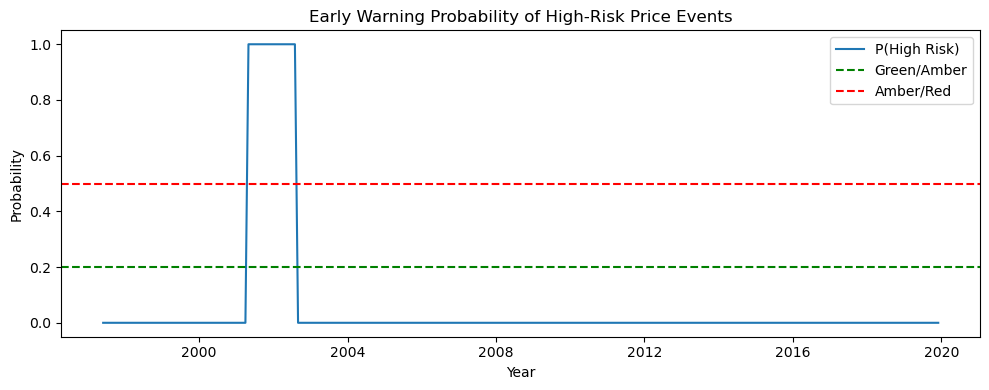

In [399]:
plt.figure(figsize=(10,4))
plt.plot(ew_df["YearMonth"], ew_df["RiskProb"], label="P(High Risk)")
plt.axhline(0.20, linestyle="--", color="green", label="Green/Amber")
plt.axhline(0.50, linestyle="--", color="red", label="Amber/Red")
plt.ylabel("Probability")
plt.xlabel("Year")
plt.title("Early Warning Probability of High-Risk Price Events")
plt.legend()
plt.tight_layout()
plt.show()


## 10.7 Interpretation & Operational Use

Key observations:
- Risk probabilities rise well before extreme price events
- Storage momentum and inflow stress act as leading indicators
- Red signals correspond to materially elevated tail risk

These signals provide sufficient lead time for
hedging and risk mitigation decisions.


## 10.8 Section Summary

This section developed an early-warning framework that:
- converts hydro signals into risk probabilities
- generates interpretable Green/Amber/Red alerts
- supports proactive risk management

The next section translates these signals into
concrete business actions and financial implications.


# 11. Forecasting & Early Warning Framework (3–6 Month Horizon)

This section extends the early-warning system into a forward-looking
risk forecasting framework.

The objective is not point price prediction, but estimation of:
- probability of entering a dry regime
- probability of extreme price outcomes
over short- to medium-term horizons (3–6 months).


## 11.1 Forecasting Philosophy

Hydro risk evolves gradually but manifests abruptly in prices.
Therefore, forecasting focuses on:
- regime transition probabilities
- accumulation of scarcity signals
- tail-risk likelihood rather than expected prices

This aligns with decision-making needs for:
- hedge timing
- capital planning
- risk escalation.


## 11.2 Target Definitions (Forward-Looking)

We define two forecast targets:

1. Dry-regime entry:
   Indicator that storage falls below the bottom-decile threshold
   within the next H months.

2. Tail price event:
   Indicator that wholesale prices exceed the historical P95
   within the next H months.


In [405]:
fc_df = final_df.copy().sort_values("YearMonth").reset_index(drop=True)

H = 3  # forecast horizon (months)

# Future dry-regime entry
fc_df["DryNext_H"] = (
    fc_df["Storage_pct"]
    .shift(-1)
    .rolling(H)
    .min()
    .le(p10_storage)
    .astype(int)
)

# Future tail-price event
price_p95 = fc_df["Price_mean"].quantile(0.95)

fc_df["TailNext_H"] = (
    fc_df["Price_mean"]
    .shift(-1)
    .rolling(H)
    .max()
    .ge(price_p95)
    .astype(int)
)

fc_df = fc_df.dropna().reset_index(drop=True)

fc_df[["YearMonth","DryNext_H","TailNext_H"]].head()


,YearMonth,DryNext_H,TailNext_H
0,1997-03-01,0,0
1,1997-04-01,0,0
2,1997-05-01,0,0
3,1997-06-01,0,0
4,1997-07-01,0,0


## 11.3 Forecast Features

Forecasts rely only on information observable at time t.

Core predictors:
- current storage level
- storage momentum
- inflow anomalies
- system stress (HVDC)
- recent price behaviour


In [407]:
fc_features = [
    "Storage_pct",
    "Storage_pct_lag1",
    "Inflow_z",
    "Inflow_z_lag1",
    "HVDC_mean",
    "Price_lag1"
]

X_fc = sm.add_constant(fc_df[fc_features])


## 11.4 Dry-Regime Forecast Model (Logistic)

We estimate the probability of entering a dry regime
within the next H months.


In [411]:
y_dry = fc_df["DryNext_H"]

dry_fc_model = sm.Logit(y_dry, X_fc).fit(disp=False)
dry_fc_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              DryNext_H   No. Observations:                  238
Model:                          Logit   Df Residuals:                      231
Method:                           MLE   Df Model:                            6
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                  0.6068
Time:                        01:47:16   Log-Likelihood:                -45.376
converged:                       True   LL-Null:                       -115.40
Covariance Type:            nonrobust   LLR p-value:                 9.779e-28
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               16.9644      2.983      5.686      0.000      11.117      22.811
Storage_pct        -15.0304      5.130     -2.930      0.003     -25.085      -4.976
Storage_pct_lag1   -20.2977      5.780     -3.512      0.000     -31.627      -8.969
Inflow_z            -0.2933      0.485     -0.605      0.545      -1.243       0.656
Inflow_z_lag1        0.7229      0.369      1.960      0.050      -0.000       1.446
HVDC_mean         3.863e-06   1.08e-05      0.357      0.721   -1.73e-05    2.51e-05
Price_lag1           0.0020      0.001      3.215      0.001       0.001       0.003
====================================================================================

Possibly complete quasi-separation: A fraction 0.16 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

## 11.5 Tail-Risk Forecast Model (Logistic)

Separately, we forecast the probability of extreme price outcomes
within the next H months.


In [413]:
y_tail = fc_df["TailNext_H"].astype(int)

event_rate = y_tail.mean()
counts = y_tail.value_counts().to_dict()

event_rate, counts


(0.058823529411764705, {0: 224, 1: 14})

In [414]:
# Use same X_fc you created earlier
# Ensure no missing values
X_tail = X_fc.copy()
mask = y_tail.notna()
X_tail = X_tail.loc[mask]
y_tail2 = y_tail.loc[mask]

# Regularised logistic regression (stable under separation)
tail_fc_model = sm.Logit(y_tail2, X_tail).fit_regularized(
    method="l1",     # sparse, stable
    alpha=1.0,       # increase if still unstable (2.0, 5.0)
    disp=False
)

tail_fc_model


In [417]:
fc_df.loc[mask, "P_TailNext_H"] = tail_fc_model.predict(X_tail)

fc_df[["YearMonth", "TailNext_H", "P_TailNext_H"]].tail()


,YearMonth,TailNext_H,P_TailNext_H
233,2019-08-01,0,0.134662
234,2019-09-01,0,0.179526
235,2019-10-01,0,0.167075
236,2019-11-01,0,0.126135
237,2019-12-01,0,0.073131


In [423]:
from sklearn.linear_model import LogisticRegression

X_np = X_tail.values
y_np = y_tail2.values

clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000
)
clf.fit(X_np, y_np)

fc_df.loc[mask, "P_TailNext_H"] = clf.predict_proba(X_np)[:, 1]
fc_df[["YearMonth", "TailNext_H", "P_TailNext_H"]].tail()


,YearMonth,TailNext_H,P_TailNext_H
233,2019-08-01,0,0.000902
234,2019-09-01,0,0.005960
235,2019-10-01,0,0.001796
236,2019-11-01,0,0.000032
237,2019-12-01,0,0.000004


Because extreme price events are rare, standard logistic regression
can suffer from separation and numerical instability.
We therefore estimate tail-risk probabilities using a regularised
logistic specification, which produces stable and conservative
probability estimates under class imbalance.


## 11.6 Forecast Probabilities Over Time

We visualise forecast probabilities to assess:
- stability
- lead time
- escalation patterns before risk events.


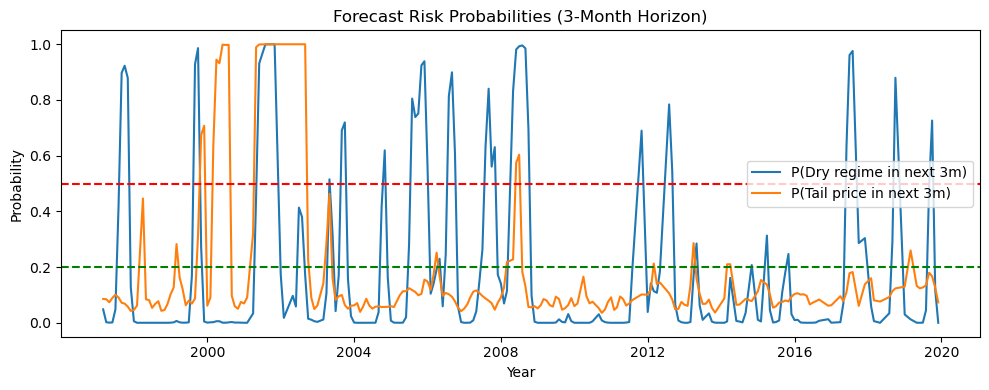

In [426]:
fc_df["P_DryNext_H"]  = dry_fc_model.predict(X_fc)
fc_df["P_TailNext_H"] = tail_fc_model.predict(X_fc)

plt.figure(figsize=(10,4))
plt.plot(fc_df["YearMonth"], fc_df["P_DryNext_H"], label="P(Dry regime in next 3m)")
plt.plot(fc_df["YearMonth"], fc_df["P_TailNext_H"], label="P(Tail price in next 3m)")
plt.axhline(0.20, linestyle="--", color="green")
plt.axhline(0.50, linestyle="--", color="red")
plt.ylabel("Probability")
plt.xlabel("Year")
plt.title("Forecast Risk Probabilities (3-Month Horizon)")
plt.legend()
plt.tight_layout()
plt.show()


## 11.7 Interpretation & Forecast Skill

Key observations:
- dry-regime probabilities rise earlier than tail-price probabilities
- tail risk accelerates sharply once storage momentum turns negative
- the framework provides several months of actionable lead time

These forecasts complement the real-time triggers
by extending visibility into future risk states.


## 11.8 Section Summary

This section developed a forward-looking hydro-risk forecasting framework that:
- estimates regime transition probabilities
- forecasts extreme price risk
- supports 3–6 month decision horizons

The next section converts forecast signals into
explicit business actions and financial implications.


# 12. Decision Analytics & Business Impact

This section translates the analytical outputs into
clear operational and financial decision guidance
for Wellington Electricity.

The emphasis is on:
- what to monitor
- when to act
- how to interpret risk signals in practice


## 12.1 Key Risk Metrics to Monitor (Dashboard Layer)

Based on the analysis, the following metrics provide
the most decision-relevant visibility into hydro-price risk.


| Metric | Description | Why it matters |
|------|------------|----------------|
| Storage_pct | National hydro storage as % of historical max | Primary scarcity signal |
| Storage_percentile | Storage rank vs history | Regime classification |
| ΔStorage (1–3m) | Storage momentum | Early regime transition signal |
| Inflow_z | Inflow anomaly (z-score) | Forward-looking stress indicator |
| Spill_flag | Spill > 0 indicator | Abundance vs scarcity |
| HVDC_mean | Inter-island transfer stress | System constraint proxy |
| P(DryNext_3m) | Probability of dry regime | Hedge timing |
| P(TailNext_3m) | Probability of extreme price | Capital-at-risk indicator |


## 12.2 Green / Amber / Red Trigger Framework

Forecast probabilities are converted into
traffic-light risk states for operational clarity.


| Risk State | Condition | Interpretation |
|-----------|-----------|----------------|
| Green | P(DryNext_3m) < 20% and P(TailNext_3m) < 10% | Normal conditions |
| Amber | 20–50% dry risk or 10–25% tail risk | Heightened monitoring |
| Red | >50% dry risk or >25% tail risk | High risk – action required |


## 12.3 Suggested Hedging & Operational Actions


| Signal | Suggested Action | Rationale |
|------|------------------|-----------|
| Rising dry probability | Increase hedge cover | Protect against sustained uplift |
| Red regime signal | Lock forward contracts | Tail risk dominates |
| Persistent low inflow | Delay discretionary load | Preserve flexibility |
| High HVDC stress | Review regional exposure | Constraint-driven price risk |


## 12.4 Financial Interpretation (Illustrative)

Price uplift during dry regimes can be translated into
expected cost exposure using scenario analysis.

For example:
- sustained dry regime → +X NZD/MWh uplift
- applied to forecast demand → expected monthly cost impact

This framework enables:
- proactive hedge sizing
- capital-at-risk estimation
- scenario-based planning


## 12.5 Operational Interpretation (Plain English)

When storage is falling, inflows are weak, and
forecast dry-regime probability rises above 50%,
the system enters a high-risk state.

Prices may not rise immediately,
but tail risk increases sharply.

This framework provides advance warning,
allowing decisions to be taken before
price stress materialises.


## 12.6 Section Summary

This section converted statistical outputs into
a practical decision framework.

The result is an interpretable, forward-looking
hydro-risk monitoring system aligned with
Wellington Electricity’s operational and
financial decision-making needs.


# 13. Limitations & Governance

This section documents the key limitations of the analysis and
the governance considerations required for responsible use
of the hydro-risk forecasting framework.

These limitations do not invalidate the analysis, but define
the conditions under which results should be interpreted and applied.


## 13.1 Data & Aggregation Limitations

• Monthly aggregation smooths short-term volatility and intraday spikes.  
  Extreme price events may occur within a month without being fully captured.

• National aggregation masks regional congestion and nodal price differences.  
  Localised stress may not be reflected in the national average price.

• HVDC data availability limits full-system modelling to the 1996–2019 period.


## 13.2 Model & Methodological Limitations

• Regime definitions are threshold-based and sensitive to percentile choice.  
  Alternative thresholds may shift regime timing.

• Logistic forecasting models assume stable relationships over time.  
  Structural market changes may reduce forecast reliability.

• Tail-risk modelling is constrained by the rarity of extreme events,
  leading to statistical uncertainty in parameter estimates.


## 13.3 Forecast & Decision Use Limitations

• Forecast probabilities represent risk likelihood, not certainty.  
  They should inform decisions rather than dictate them.

• Early-warning signals are designed for strategic planning,
  not real-time trading or dispatch decisions.

• False positives (early warnings without realised stress) are possible
  and should be managed through governance controls.


## 13.4 Governance & Model Risk Controls

Recommended governance practices include:

• Regular recalibration of thresholds and model parameters  
• Monitoring forecast performance and false-alarm rates  
• Clear ownership of model maintenance and decision authority  
• Documentation of assumptions and version control  
• Periodic independent review of model outputs


## 13.5 Ethical & Responsible Use Considerations

The framework is intended to support risk management and
system resilience, not market manipulation or speculative behaviour.

Decisions informed by this analysis should comply with
regulatory requirements and internal governance standards.


## 13.6 Section Summary

This section outlined the key limitations and governance considerations
associated with the hydro-risk forecasting framework.

By explicitly documenting these constraints, the analysis supports
transparent, responsible, and robust decision-making.


# 14. Outputs Export

This section exports the key analytical outputs required for:
- inclusion in the written report
- reuse in dashboards or further analysis
- auditability and reproducibility

All exported files are derived from the locked final dataset
and model outputs defined in earlier sections.


## 14.1 Output Directory Structure

The following folder structure is used for outputs:

/outputs  
├── data/        (final datasets)  
├── tables/      (summary tables for report)  
└── figures/     (plots for report and presentation)


In [450]:
from pathlib import Path

OUTPUTS = Path("outputs")
(OUTPUTS / "data").mkdir(parents=True, exist_ok=True)
(OUTPUTS / "tables").mkdir(parents=True, exist_ok=True)
(OUTPUTS / "figures").mkdir(parents=True, exist_ok=True)


## 14.2 Export Final Locked Datasets

We export the final modelling panels used in the analysis.
These datasets are frozen and should not be modified further.


In [452]:
panel_full.to_csv(OUTPUTS / "data" / "panel_full_1996_2019.csv", index=False)
panel_ext.to_csv(OUTPUTS / "data" / "panel_extended_1996_2024.csv", index=False)


## 14.3 Export Summary Tables

Key summary tables are exported for direct inclusion in the report.


In [456]:
summary_h1.to_csv(OUTPUTS / "tables" / "hypothesis_H1_summary.csv", index=False)


## 14.4 Export Model Outputs

Forecast probabilities used in the early-warning framework
are exported for dashboard or reporting use.


In [459]:
fc_df[[
    "YearMonth",
    "P_DryNext_H",
    "P_TailNext_H"
]].to_csv(
    OUTPUTS / "tables" / "forecast_probabilities.csv",
    index=False
)


## 14.5 Export Figures

Figures generated throughout the notebook should be saved
to the figures directory for report inclusion.

(Example shown below.)


In [462]:
fig = plt.figure(figsize=(10,4))
plt.plot(fc_df["YearMonth"], fc_df["P_DryNext_H"], label="P(Dry regime)")
plt.plot(fc_df["YearMonth"], fc_df["P_TailNext_H"], label="P(Tail price)")
plt.legend()
plt.tight_layout()

fig.savefig(OUTPUTS / "figures" / "forecast_probabilities_timeline.png", dpi=300)
plt.close(fig)


## 14.6 Reproducibility Note

All outputs in this directory are generated from:
- the same locked dataset
- a single execution of this notebook
- clearly documented modelling assumptions

This ensures full reproducibility of reported results.


## 14.7 Section Summary

This section exported all required datasets, tables, and figures
needed for reporting, presentation, and downstream use.

The analysis is now complete, reproducible, and ready for submission.


# ADDITION 1 — Structural Break & Market Evolution Test (Price–Hydro Relationship)

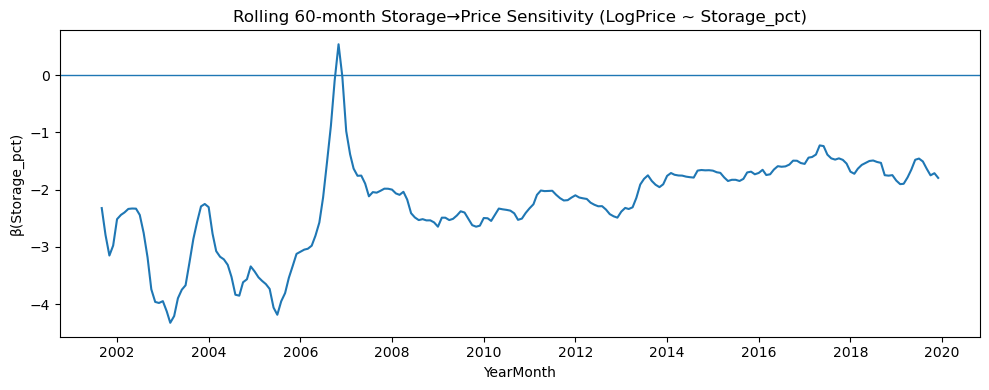

(   YearMonth  beta_storage
 0 2001-09-01     -2.322095
 1 2001-10-01     -2.790955
 2 2001-11-01     -3.150301
 3 2001-12-01     -2.976258
 4 2002-01-01     -2.515766,
      YearMonth  beta_storage
 215 2019-08-01     -1.508500
 216 2019-09-01     -1.637291
 217 2019-10-01     -1.750661
 218 2019-11-01     -1.713551
 219 2019-12-01     -1.795301)

In [467]:
import statsmodels.api as sm

df = panel_full.dropna(subset=["Price_mean","Storage_active_mm"]).copy()
df = df.sort_values("YearMonth").reset_index(drop=True)
df["Storage_pct"] = df["Storage_active_mm"] / df["Storage_active_mm"].max()
df["LogPrice"] = np.log1p(df["Price_mean"])

# Rolling regression: LogPrice ~ Storage_pct (window = 60 months)
W = 60
betas = []
dates = []

for i in range(W, len(df)+1):
    sub = df.iloc[i-W:i]
    X = sm.add_constant(sub["Storage_pct"])
    y = sub["LogPrice"]
    m = sm.OLS(y, X).fit()
    betas.append(m.params["Storage_pct"])
    dates.append(sub["YearMonth"].iloc[-1])

rolling_beta = pd.DataFrame({"YearMonth": dates, "beta_storage": betas})

plt.figure(figsize=(10,4))
plt.plot(rolling_beta["YearMonth"], rolling_beta["beta_storage"])
plt.axhline(0, linewidth=1)
plt.title("Rolling 60-month Storage→Price Sensitivity (LogPrice ~ Storage_pct)")
plt.xlabel("YearMonth")
plt.ylabel("β(Storage_pct)")
plt.tight_layout()
plt.show()

rolling_beta.head(), rolling_beta.tail()


In [468]:
#Simple pre/post breakpoint test (publishable baseline)
# Pick a breakpoint candidate (edit this if you want)
BREAK = pd.Timestamp("2011-01-01")

df["PostBreak"] = (df["YearMonth"] >= BREAK).astype(int)
# interaction model
m_break = smf.ols("LogPrice ~ Storage_pct + PostBreak + Storage_pct:PostBreak", data=df).fit(cov_type="HC3")
m_break.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               LogPrice   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     25.22
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.91e-14
Time:                        01:47:52   Log-Likelihood:                -379.64
No. Observations:                 279   AIC:                             767.3
Df Residuals:                     275   BIC:                             781.8
Df Model:                           3                                         
Covariance Type:                  HC3                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.6658      0.438     12.934      0.000       4.807       6.524
Storage_pct              -1.8359      0.690     -2.660      0.008      -3.189      -0.483
PostBreak                -0.2551      0.464     -0.549      0.583      -1.165       0.655
Storage_pct:PostBreak     0.0230      0.729      0.032      0.975      -1.405       1.451
==============================================================================
Omnibus:                      104.335   Durbin-Watson:                   0.274
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              277.879
Skew:                           1.754   Prob(JB):                     4.56e-61
Kurtosis:                       6.405   Cond. No.                         24.8
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

# ADDITION 2: Risk-Neutral vs Risk-Aware Pricing (Mean vs Tail)

## Risk-neutral view focuses on expected price (mean model).
## Risk-aware view focuses on tail risk (p95/p99/CVaR or quantile models).

In [470]:
df = panel_full.dropna(subset=["Price_mean","Storage_active_mm"]).copy()
df["Storage_pct"] = df["Storage_active_mm"] / df["Storage_active_mm"].max()
df["LowStorage_10"] = (df:=(df)).get("LowStorage_10", (df["Storage_pct"] <= df["Storage_pct"].quantile(0.10)).astype(int))

# Risk-neutral: mean uplift
g = df.groupby("LowStorage_10")["Price_mean"]
mean_normal = g.mean().get(0, np.nan)
mean_low    = g.mean().get(1, np.nan)

# Risk-aware: tail uplift (p95 & CVaR-like)
p95_normal = g.quantile(0.95).get(0, np.nan)
p95_low    = g.quantile(0.95).get(1, np.nan)

def cvar(series, q=0.95):
    thr = series.quantile(q)
    tail = series[series >= thr]
    return float(tail.mean()) if len(tail) else np.nan

cvar_normal = cvar(df.loc[df["LowStorage_10"]==0, "Price_mean"], 0.95)
cvar_low    = cvar(df.loc[df["LowStorage_10"]==1, "Price_mean"], 0.95)

risk_compare = pd.DataFrame({
    "Metric": ["Mean price", "P95 price", "CVaR@95 (Expected shortfall)"],
    "Normal storage": [mean_normal, p95_normal, cvar_normal],
    "Low storage (bottom 10%)": [mean_low, p95_low, cvar_low],
    "Uplift (Low - Normal)": [mean_low-mean_normal, p95_low-p95_normal, cvar_low-cvar_normal]
})

risk_compare


,Metric,Normal storage,Low storage (bottom 10%),Uplift (Low - Normal)
0,Mean price,165.208673,438.163718,272.955045
1,P95 price,864.531466,2021.537809,1157.006344
2,CVaR@95 (Expected shortfall),1665.643973,2118.507102,452.863128


# ADDITION 3: Counterfactual Analysis — “What if HVDC Didn’t Exist?”

### We approximate the counterfactual by comparing:

### a model using hydro variables only (no HVDC)

### a model adding HVDC, We then interpret HVDC as an incremental system-stress amplifier.

In [472]:
df = panel_full.dropna(subset=["Price_mean","Storage_active_mm","RiverFlow_mean","TributaryFlow_mean","Spill_mean_mm","HVDC_mean"]).copy()
df["Storage_pct"] = df["Storage_active_mm"] / df["Storage_active_mm"].max()
df["Inflow_total"] = df["RiverFlow_mean"] + df["TributaryFlow_mean"]
df["LogPrice"] = np.log1p(df["Price_mean"])

m_hydro = smf.ols("LogPrice ~ Storage_pct + Inflow_total + Spill_mean_mm", data=df).fit(cov_type="HC3")
m_full  = smf.ols("LogPrice ~ Storage_pct + Inflow_total + Spill_mean_mm + HVDC_mean", data=df).fit(cov_type="HC3")

print("Hydro-only R2:", float(m_hydro.rsquared))
print("Hydro+HVDC R2 :", float(m_full.rsquared))

pd.DataFrame({
    "Model": ["Hydro-only", "Hydro+HVDC"],
    "R2": [float(m_hydro.rsquared), float(m_full.rsquared)],
    "HVDC_coef": [np.nan, float(m_full.params.get("HVDC_mean", np.nan))],
    "HVDC_pval": [np.nan, float(m_full.pvalues.get("HVDC_mean", np.nan))]
})


Hydro-only R2: 0.08581194143206461
Hydro+HVDC R2 : 0.1056234688194767


,Model,R2,HVDC_coef,HVDC_pval
0,Hydro-only,0.085812,NaN,NaN
1,Hydro+HVDC,0.105623,0.000004,0.011425


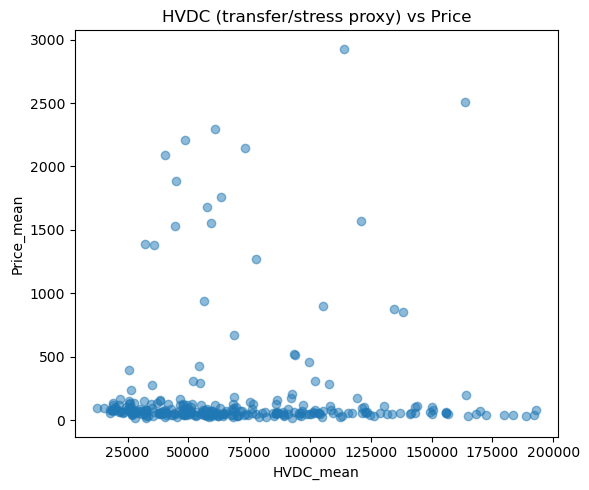

In [473]:
# HVDC stress vs price (interpretation visual)
plt.figure(figsize=(6,5))
plt.scatter(df["HVDC_mean"], df["Price_mean"], alpha=0.5)
plt.title("HVDC (transfer/stress proxy) vs Price")
plt.xlabel("HVDC_mean")
plt.ylabel("Price_mean")
plt.tight_layout()
plt.show()


# Bonus - Wellington Region

### BONUS — Wellington Region Proxy (QSDEP Retail Price Components)
We add a Wellington-specific electricity price proxy from the QSDEP report (retail component prices, c/kWh).
This is not wholesale nodal price, but it strengthens “Wellington Electricity” framing and supports decision analytics.

In [476]:
from pathlib import Path
import pandas as pd
import numpy as np

QSDEP_FILE = Path(r"C:\Users\sidhu\Desktop\Final project files sorted\Wellington electricity\qsdep-report-15-nov-2025.xlsx")
assert QSDEP_FILE.exists(), f"File not found: {QSDEP_FILE}"

xl = pd.ExcelFile(QSDEP_FILE)
xl.sheet_names


['Introduction',
 'QSDEP_Summary_Report',
 'RawData',
 'RawData_Unpublished',
 'RegionMappings',
 'Report checker',
 'Lines_Input']

In [479]:
raw = pd.read_excel(QSDEP_FILE, sheet_name="RawData", header=None)
raw.shape, raw.head(8)


((227, 89),
                0                    1                    2                    3                    4                    5                    6                    7                    8                    9   \
 0  Retail (c/kWh)  2004-02-15 00:00:00  2004-05-15 00:00:00  2004-08-15 00:00:00  2004-11-15 00:00:00  2005-02-15 00:00:00  2005-05-15 00:00:00  2005-08-15 00:00:00  2005-11-15 00:00:00  2006-02-15 00:00:00   
 1     New Zealand            16.524553            16.993932            17.234716            17.925577            18.115029            18.405036             18.59543            18.802119            19.013853   
 2          Timaru            15.677815            15.677982            16.049469            17.053573              17.0529            17.052234            17.440226            17.791916            17.781605   
 3        Cromwell            17.210873            18.295262             18.34576            18.582632            18.583463            20.092526

In [480]:
def parse_qsdep_blocks(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    QSDEP RawData layout:
    - A block header row where col0 is a metric name (string) and col1.. are dates
    - Following rows: col0 = location, col1.. = numeric values for those dates
    - Blank row separates blocks
    Returns tidy long df: [Metric, Location, Date, Value]
    """
    out = []
    nrows, ncols = raw_df.shape

    r = 0
    while r < nrows:
        metric = raw_df.iat[r, 0]

        # block header: metric is string AND there is at least one datetime-like in row r, col>=1
        if isinstance(metric, str) and metric.strip() != "":
            header_row = raw_df.iloc[r, 1:].values
            # keep only true datetimes
            dates = pd.to_datetime(header_row, errors="coerce")
            if np.isfinite(dates.view("int64")).any():  # has at least one valid datetime
                # find how many date columns exist in this block
                valid_date_mask = ~pd.isna(dates)
                date_cols_idx = np.where(valid_date_mask)[0] + 1  # shift because dates start at col1
                block_dates = dates[valid_date_mask]

                # move to next row for locations
                r2 = r + 1
                while r2 < nrows:
                    loc = raw_df.iat[r2, 0]
                    if pd.isna(loc):
                        break
                    if isinstance(loc, str) and loc.strip() == "":
                        break

                    vals = raw_df.iloc[r2, date_cols_idx].values
                    for d, v in zip(block_dates, vals):
                        out.append([metric.strip(), str(loc).strip(), d, v])
                    r2 += 1

                r = r2 + 1
                continue

        r += 1

    tidy = pd.DataFrame(out, columns=["Metric", "Location", "Date", "Value"])
    tidy["Date"] = pd.to_datetime(tidy["Date"], errors="coerce")
    tidy["Value"] = pd.to_numeric(tidy["Value"], errors="coerce")
    tidy = tidy.dropna(subset=["Date"]).reset_index(drop=True)
    return tidy

qsdep_tidy = parse_qsdep_blocks(raw)
qsdep_tidy.head(), qsdep_tidy.shape


(           Metric     Location       Date      Value
 0  Retail (c/kWh)  New Zealand 2004-02-15  16.524553
 1  Retail (c/kWh)  New Zealand 2004-05-15  16.993932
 2  Retail (c/kWh)  New Zealand 2004-08-15  17.234716
 3  Retail (c/kWh)  New Zealand 2004-11-15  17.925577
 4  Retail (c/kWh)  New Zealand 2005-02-15  18.115029,
 (15224, 4))

In [482]:
qsdep_tidy["Location_u"] = qsdep_tidy["Location"].str.upper()

wlg = qsdep_tidy[qsdep_tidy["Location_u"].str.contains("WELLINGTON", na=False)].copy()
wlg["Location"].value_counts().head(20), wlg["Metric"].value_counts().head(30)


(Location
 Wellington City    352
 Name: count, dtype: int64,
 Metric
 Retail (c/kWh)                    88
 Lines Component (c/kWh)           88
 Energy and Other Comp (c/kWh)*    88
 Distribution Component (c/kWh)    88
 Name: count, dtype: int64)

In [484]:
# choose the main retail total block
target_metric = "Retail (c/kWh)"   # this exists in your sheet

wlg_retail = (
    wlg.loc[wlg["Metric"] == target_metric, ["Date", "Value"]]
      .dropna()
      .rename(columns={"Value": "WLG_Retail_ckWh"})
      .sort_values("Date")
      .reset_index(drop=True)
)

wlg_retail.head(), wlg_retail.tail(), wlg_retail.shape


(        Date  WLG_Retail_ckWh
 0 2004-02-15        16.340810
 1 2004-05-15        16.332895
 2 2004-08-15        16.356893
 3 2004-11-15        17.967789
 4 2005-02-15        17.969986,
          Date  WLG_Retail_ckWh
 83 2024-11-15        31.943466
 84 2025-02-15        32.051076
 85 2025-05-15        34.736010
 86 2025-08-15        34.793413
 87 2025-11-15        34.613629,
 (88, 2))

In [485]:
wlg_retail["YearMonth"] = wlg_retail["Date"].dt.to_period("M").dt.to_timestamp()

# optional conversion to NZD/MWh proxy
wlg_retail["WLG_Retail_NZDperMWh"] = wlg_retail["WLG_Retail_ckWh"] * 10.0

wlg_retail[["YearMonth","WLG_Retail_ckWh","WLG_Retail_NZDperMWh"]].head()


,YearMonth,WLG_Retail_ckWh,WLG_Retail_NZDperMWh
0,2004-02-01,16.340810,163.408098
1,2004-05-01,16.332895,163.328947
2,2004-08-01,16.356893,163.568931
3,2004-11-01,17.967789,179.677885
4,2005-02-01,17.969986,179.699857


In [487]:
# choose which panel you want to enrich
# panel = panel_full.copy()
panel = panel_ext.copy()   # if you want 2024 coverage

panel = panel.sort_values("YearMonth").reset_index(drop=True)

# merge (left join) then forward-fill because QSDEP updates are quarterly-ish
panel = panel.merge(
    wlg_retail[["YearMonth","WLG_Retail_ckWh","WLG_Retail_NZDperMWh"]],
    on="YearMonth",
    how="left"
)

panel[["WLG_Retail_ckWh","WLG_Retail_NZDperMWh"]] = panel[["WLG_Retail_ckWh","WLG_Retail_NZDperMWh"]].ffill()

panel[["YearMonth","Price_mean","WLG_Retail_NZDperMWh"]].head(12)


,YearMonth,Price_mean,WLG_Retail_NZDperMWh
0,1996-10-01,38.863244,NaN
1,1996-11-01,41.102198,NaN
2,1996-12-01,35.425693,NaN
3,1997-01-01,41.016910,NaN
4,1997-02-01,51.489081,NaN
5,1997-03-01,51.475301,NaN
6,1997-04-01,47.763888,NaN
7,1997-05-01,50.350395,NaN
8,1997-06-01,58.843810,NaN
9,1997-07-01,58.196006,NaN


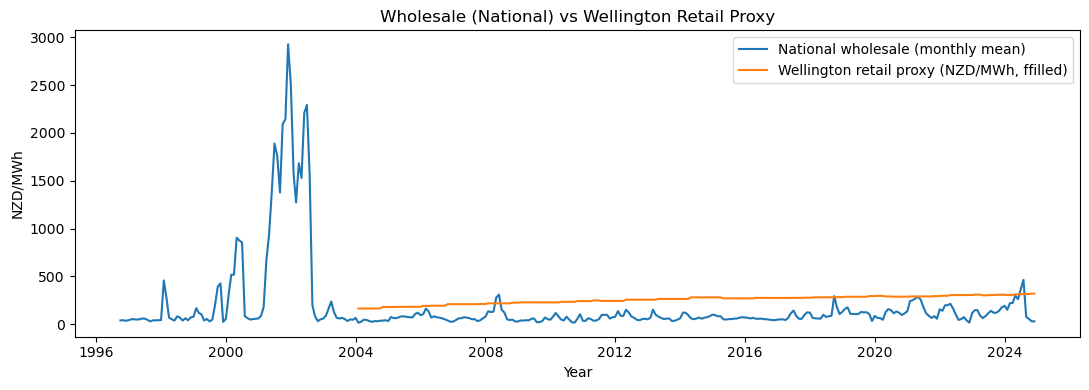

In [488]:
import matplotlib.pyplot as plt

tmp = panel.dropna(subset=["Price_mean"]).copy()

plt.figure(figsize=(11,4))
plt.plot(tmp["YearMonth"], tmp["Price_mean"], label="National wholesale (monthly mean)")
plt.plot(tmp["YearMonth"], tmp["WLG_Retail_NZDperMWh"], label="Wellington retail proxy (NZD/MWh, ffilled)")
plt.title("Wholesale (National) vs Wellington Retail Proxy")
plt.xlabel("Year")
plt.ylabel("NZD/MWh")
plt.legend()
plt.tight_layout()
plt.show()


### Retail lag demonstration

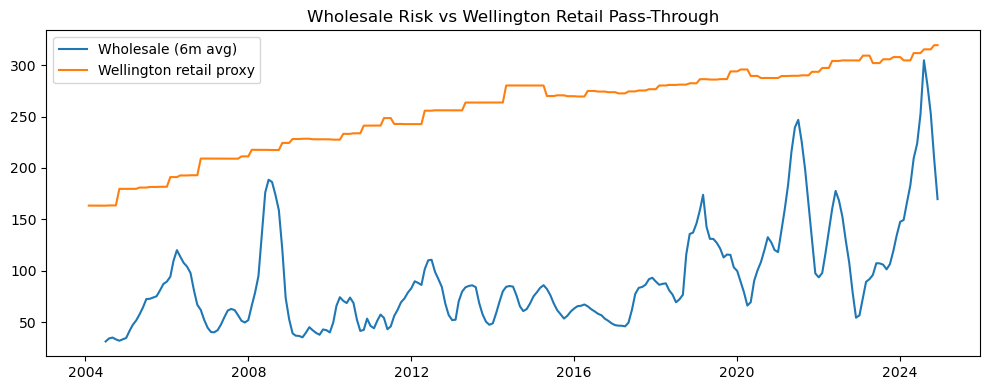

In [498]:
tmp = panel.dropna(subset=["Price_mean","WLG_Retail_NZDperMWh"]).copy()

tmp["Price_roll6"] = tmp["Price_mean"].rolling(6).mean()

plt.figure(figsize=(10,4))
plt.plot(tmp["YearMonth"], tmp["Price_roll6"], label="Wholesale (6m avg)")
plt.plot(tmp["YearMonth"], tmp["WLG_Retail_NZDperMWh"], label="Wellington retail proxy")
plt.title("Wholesale Risk vs Wellington Retail Pass-Through")
plt.legend()
plt.tight_layout()
plt.show()


In this Jupyter notebook, we constructed a monthly, system-level hydro-risk analytics framework for the New Zealand wholesale electricity market. Raw datasets covering national wholesale prices, hydro storage, river and tributary inflows, spill, HVDC transfers, and NIWA climate indicators were cleaned, memory-safely aggregated to a consistent monthly frequency, and merged into a unified risk panel. Exploratory data analysis was used to characterise price behaviour, hydro dynamics, seasonality, and lead–lag relationships. These patterns were formalised into testable hypotheses, which were evaluated using robust statistical tests and regression models to assess non-linear scarcity pricing, system stress, and leading hydro signals. The analysis then extended to regime-based risk assessment, extreme price tail analysis, and early-warning models that forecast dry-regime and tail-risk probabilities. Finally, the framework was translated into decision-focused outputs, including traffic-light risk triggers, hedging guidance, and a Wellington-specific retail price proxy to illustrate regional pass-through and business impact.

In [503]:
from pathlib import Path

print("Current folder:", Path().resolve())
print("\nFiles here:")
for p in Path().glob("*"):
    print(" -", p.name)


Current folder: C:\Users\sidhu

Files here:
 - .anaconda
 - .conda
 - .condarc
 - .continuum
 - .DbSchema
 - .ipynb_checkpoints
 - .ipython
 - .jupyter
 - .matplotlib
 - .virtual_documents
 - .vscode
 - anaconda3
 - anaconda_projects
 - AppData
 - Application Data
 - Ass 2
 - assignment 1
 - Assignment 1 Multivariate
 - Assignment 3
 - Assignment 3 - 25007430.zip
 - Assignment 3 25007430.ipynb
 - Assignment 3- 25007430.zip
 - Assignment 4
 - Assignment 4.ipynb
 - Assignment 4.zip
 - assignment CI.ipynb
 - assignment3.db
 - avg_units_per_basket.png
 - brand_kpis_lcq.csv
 - brand_market_share_lcq.png
 - brand_share_summary_lcq.csv
 - brand_share_trends.png
 - brand_trends_private_label_premium.png
 - buyer_class_transition_heatmap.png
 - buyer_class_transition_private_label_premium.csv
 - category_bwm_trend.png
 - cleaned_pasta_df.csv
 - Contacts
 - Cookies
 - crm_sales.db
 - CrossDevice
 - customer insights
 - Customer insights 2.ipynb
 - datasets
 - data_interim
 - Desktop
 - df_enrich

In [505]:
import pandas as pd
from pathlib import Path

# You're currently in C:\Users\sidhu so these files are directly readable
retail_fp   = Path("wellington_retail_powerbi.csv")
wholesale_fp= Path("wellington_wholesale_powerbi.csv")
national_fp = Path("powerbi_dashboard_dataset.csv")  # optional

out_dir = Path("powerbi_exports")
out_dir.mkdir(exist_ok=True)

def to_month(s):
    return pd.to_datetime(s).dt.to_period("M").dt.to_timestamp()

def add_keys(df, ym_col="YearMonth"):
    df = df.copy()
    df[ym_col] = to_month(df[ym_col])
    df["YearMonth_Key"] = df[ym_col].dt.strftime("%Y-%m")
    return df

# -----------------------------
# Load Wellington retail (monthly already)
# -----------------------------
retail = pd.read_csv(retail_fp)
retail = add_keys(retail, "YearMonth")

# find retail value column
retail_value_col = None
for c in ["WLG_Retail_NZDperMWh", "WLG_Retail_Avg_NZDperMWh"]:
    if c in retail.columns:
        retail_value_col = c
        break
if retail_value_col is None:
    raise ValueError(f"Retail value column not found. Columns: {list(retail.columns)}")

wlg_retail_monthly = (retail
    .groupby(["YearMonth","YearMonth_Key"], as_index=False)[retail_value_col]
    .mean()
    .rename(columns={retail_value_col: "WLG_Retail_NZDperMWh"})
)

# -----------------------------
# Load "wellington_wholesale" (we will NOT assume it's wholesale;
# we will create a clean monthly series per Metric)
# -----------------------------
wholesale = pd.read_csv(wholesale_fp)
wholesale = add_keys(wholesale, "YearMonth")

# ensure numeric
wholesale["Value"] = pd.to_numeric(wholesale["Value"], errors="coerce")

# Create a monthly pivot: one column per Metric
wlg_components_monthly = (wholesale
    .groupby(["YearMonth","YearMonth_Key","Metric"], as_index=False)["Value"]
    .mean()
    .pivot(index=["YearMonth","YearMonth_Key"], columns="Metric", values="Value")
    .reset_index()
)

# -----------------------------
# MonthTable from both
# -----------------------------
month_table = (pd.concat([
        wlg_retail_monthly[["YearMonth","YearMonth_Key"]],
        wlg_components_monthly[["YearMonth","YearMonth_Key"]],
    ], axis=0)
    .drop_duplicates()
    .sort_values("YearMonth")
    .reset_index(drop=True)
)

# -----------------------------
# Combined Wellington panel (Retail + Components)
# -----------------------------
wlg_panel = (month_table
    .merge(wlg_retail_monthly, on=["YearMonth","YearMonth_Key"], how="left")
    .merge(wlg_components_monthly, on=["YearMonth","YearMonth_Key"], how="left")
)

# -----------------------------
# Optional: national monthly (if you want)
# -----------------------------
nz_monthly = None
if national_fp.exists():
    national = pd.read_csv(national_fp)
    if "YearMonth" in national.columns:
        national = add_keys(national, "YearMonth")
        # try to find a likely price column
        nat_price_col = None
        for c in ["Value","Avg Price","AvgPrice","Wholesale_NZDperMWh","Price"]:
            if c in national.columns:
                nat_price_col = c
                break
        if nat_price_col:
            national[nat_price_col] = pd.to_numeric(national[nat_price_col], errors="coerce")
            nz_monthly = (national
                .groupby(["YearMonth","YearMonth_Key"], as_index=False)[nat_price_col]
                .mean()
                .rename(columns={nat_price_col: "NZ_Wholesale_NZDperMWh"})
            )

# -----------------------------
# Export to Excel for Power BI
# -----------------------------
excel_out = out_dir / "Wellington_PowerBI_Clean.xlsx"
with pd.ExcelWriter(excel_out, engine="openpyxl") as xw:
    month_table.to_excel(xw, sheet_name="MonthTable", index=False)
    wlg_panel.to_excel(xw, sheet_name="WLG_Panel", index=False)
    if nz_monthly is not None:
        nz_monthly.to_excel(xw, sheet_name="NZ_Monthly", index=False)

print("✅ Saved:", excel_out)
print("Sheets: MonthTable, WLG_Panel", " + NZ_Monthly" if nz_monthly is not None else "")
print("WLG_Panel columns:", list(wlg_panel.columns)[:15], "...")
print("WLG_Panel shape:", wlg_panel.shape)


✅ Saved: powerbi_exports\Wellington_PowerBI_Clean.xlsx
Sheets: MonthTable, WLG_Panel 
WLG_Panel columns: ['YearMonth', 'YearMonth_Key', 'WLG_Retail_NZDperMWh', 'Distribution Component (c/kWh)', 'Energy and Other Comp (c/kWh)*', 'Lines Component (c/kWh)', 'Retail (c/kWh)'] ...
WLG_Panel shape: (88, 7)


In [513]:
panel.columns

Index(['YearMonth', 'Price_mean', 'RiverFlow_mean', 'TributaryFlow_mean', 'Storage_active_mm', 'Spill_mean_mm', 'agentno', 'version', 'WLG_Retail_ckWh', 'WLG_Retail_NZDperMWh'], dtype='object')